# EFW Annual Changes and Macroeconomic Trajectories: A Deep Empirical Analysis (2000–2023)

**Research Notebook** | Economic Freedom and Macroeconomic Dynamics

This notebook provides a rigorous empirical exploration of the relationship between changes in the Economic Freedom of the World (EFW) index and macroeconomic outcomes. The analysis is designed to inform subsequent causal research by:

1. **Trajectory Analysis**: Examining how macroeconomic variables evolve before, during, and after EFW changes
2. **Asymmetry Analysis**: Testing whether EFW increases and decreases have symmetric effects
3. **State-Dependence**: Investigating whether initial conditions moderate the EFW-macro relationship
4. **Non-linearities**: Exploring whether the magnitude of EFW changes matters (threshold effects)
5. **Logarithmic Specifications**: Assessing whether percentage changes dominate level changes

**Key Macroeconomic Variables** (prioritizing Penn World Tables):
- Real GDP (rgdpna), GDP per capita (rgdpe/pop)
- Human Capital Index (hc)
- Consumption (rconna, csh_c)
- Government Expenditure (csh_g)
- Investment (csh_i)
- Capital Stock (rkna)
- Total Factor Productivity (rtfpna, ctfp)
- Welfare (see Feenstra et al. methodology)
- Real Internal Rate of Return (irr)
- Trade shares (csh_x, csh_m)
- WDI fallbacks: inflation, growth rates

## Research Design and Methodological Framework

### Conceptual Framework

Economic reforms (proxied by EFW changes) can affect macroeconomic outcomes through multiple channels:
- **Supply-side**: Improved resource allocation → higher TFP and capital deepening
- **Demand-side**: Investment stimulus, consumption smoothing, trade expansion
- **Expectations channel**: Policy credibility → lower risk premia, increased investment

### Key Identification Challenges (Descriptive Preview)
1. **Reverse causality**: Economic performance may drive reforms
2. **Selection**: Reform timing is endogenous
3. **Omitted variables**: Political cycles, global shocks

This notebook provides *descriptive* patterns to inform subsequent causal analysis.

### Data Sources
- **EFW Annual Panel** (Fraser Institute, 2000–2023)
- **Penn World Tables 10.01** (Feenstra, Inklaar, Timmer): rgdpe, rgdpna, hc, rkna, rtfpna, irr, ctfp, csh_c, csh_g, csh_i, csh_x, csh_m
- **World Development Indicators**: inflation, GDP growth (fallback)
- **Elections Master DPI**: Political timing controls

### Output Structure
- Tables: `outputs/tables/03_efw_annual_elections_macro_presentable/`
- Figures: `outputs/figures/03_efw_annual_elections_macro_presentable/`
- Logs: `outputs/logs/03_efw_annual_elections_macro_presentable/`

In [3]:
# =============================================================================
# Section 1: Environment Setup and Core Infrastructure
# =============================================================================

from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
import scipy
from scipy.stats import ttest_ind, mannwhitneyu, spearmanr, pearsonr
import warnings
import json
import random
import sys
from datetime import datetime
from IPython.display import display, Markdown
from typing import Literal, Optional, Tuple, List, Dict

# Suppress specific warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

pd.options.mode.copy_on_write = True
pd.options.display.max_columns = 50
pd.options.display.float_format = '{:.4f}'.format

%matplotlib inline

# =============================================================================
# Path Configuration
# =============================================================================

def find_repo_root(start: Path | None = None) -> Path:
    """Find repository root by looking for data/ and notebooks/ directories."""
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / 'data').exists() and (p / 'notebooks').exists():
            return p
    raise ValueError('Repo root not found; expected data/ and notebooks/ in a parent directory')

ROOT = find_repo_root()

PATHS = {
    'data_processed': ROOT / 'data' / 'processed',
    'data_raw': ROOT / 'data' / 'raw',
}

NOTEBOOK_NAME = '03_efw_annual_elections_macro_presentable'
OUT_ROOT = ROOT / 'outputs'
OUT_FIG = OUT_ROOT / 'figures' / NOTEBOOK_NAME
OUT_TAB = OUT_ROOT / 'tables' / NOTEBOOK_NAME
OUT_LOG = OUT_ROOT / 'logs' / NOTEBOOK_NAME
for p in [OUT_FIG, OUT_TAB, OUT_LOG]:
    p.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# =============================================================================
# Academic-Quality Plot Configuration (AER/QJE Style)
# =============================================================================

# Define color palette optimized for academic publishing and colorblind accessibility
COLORS = {
    'increase': '#2171b5',      # Blue for EFW increases
    'decrease': '#cb181d',      # Red for EFW decreases
    'neutral': '#525252',       # Gray for baseline/neutral
    'highlight': '#238b45',     # Green for highlights
    'ci_fill': '#d9d9d9',       # Light gray for confidence intervals
    'grid': '#e0e0e0',          # Very light gray for grid
    'high_initial': '#984ea3',  # Purple for high initial state
    'low_initial': '#ff7f00',   # Orange for low initial state
}

# Publication-quality plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    # Figure
    'figure.dpi': 150,
    'figure.figsize': (8, 5),
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    
    # Fonts (use serif for academic look)
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    
    # Axes
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    
    # Grid
    'grid.color': COLORS['grid'],
    'grid.linewidth': 0.5,
    'grid.alpha': 0.7,
    
    # Lines and markers
    'lines.linewidth': 1.8,
    'lines.markersize': 6,
    
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#cccccc',
    'legend.fancybox': False,
    
    # Ticks
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
})

# =============================================================================
# Utility Functions
# =============================================================================

def read_parquet_pyarrow(path: str | Path) -> pd.DataFrame:
    """Read parquet file using PyArrow for consistency."""
    table = pq.read_table(str(path))
    return table.to_pandas()


def write_parquet_pyarrow(df: pd.DataFrame, path: str | Path) -> None:
    """Write DataFrame to parquet with PyArrow."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    table = pa.Table.from_pandas(df, preserve_index=False)
    pq.write_table(table, str(path))


def save_table(df: pd.DataFrame, name: str, *, index: bool = False, also_md: bool = True) -> None:
    """Save table in multiple formats for reproducibility."""
    write_parquet_pyarrow(df, OUT_TAB / f"{name}.parquet")
    df.to_csv(OUT_TAB / f"{name}.csv", index=index)
    if also_md:
        df_md = df.astype(object).where(pd.notna(df), None)
        (OUT_TAB / f"{name}.md").write_text(df_md.to_markdown(index=index, missingval=""))


def save_log(df: pd.DataFrame, name: str, *, index: bool = False) -> None:
    """Save log file for audit trail."""
    write_parquet_pyarrow(df, OUT_LOG / f"{name}.parquet")
    df.to_csv(OUT_LOG / f"{name}.csv", index=index)


def save_fig(name: str, fig=None, formats: list = ['png', 'pdf']) -> None:
    """Save figure in multiple formats for publication."""
    fig = fig or plt.gcf()
    for fmt in formats:
        fig.savefig(OUT_FIG / f"{name}.{fmt}", bbox_inches='tight', dpi=300 if fmt=='png' else None)


def assert_unique(df: pd.DataFrame, keys: list[str], allow_na: bool = False) -> None:
    """Assert no duplicate rows on key columns."""
    if not allow_na and df[keys].isna().any().any():
        raise AssertionError(f"Missing values in key columns {keys}")
    dupes = df.duplicated(subset=keys)
    if dupes.any():
        raise AssertionError(f"Duplicate rows found on keys {keys}: {int(dupes.sum())}")


def winsorize_series(s: pd.Series, lower: float = 0.01, upper: float = 0.99) -> pd.Series:
    """Winsorize a series at given percentiles to handle outliers."""
    lo_val = s.quantile(lower)
    hi_val = s.quantile(upper)
    return s.clip(lower=lo_val, upper=hi_val)


def bootstrap_ci(data: np.ndarray, statistic=np.mean, n_bootstrap: int = 1000, 
                 ci: float = 0.95, seed: int = SEED) -> Tuple[float, float]:
    """Compute bootstrap confidence interval for a statistic."""
    rng = np.random.RandomState(seed)
    data = np.array(data)
    data = data[~np.isnan(data)]
    if len(data) < 3:
        return np.nan, np.nan
    boot_stats = [statistic(rng.choice(data, size=len(data), replace=True)) for _ in range(n_bootstrap)]
    alpha = (1 - ci) / 2
    return np.percentile(boot_stats, alpha * 100), np.percentile(boot_stats, (1 - alpha) * 100)


def cohen_d(group1: np.ndarray, group2: np.ndarray) -> float:
    """Compute Cohen's d effect size for two groups."""
    g1 = np.array(group1)[~np.isnan(group1)]
    g2 = np.array(group2)[~np.isnan(group2)]
    if len(g1) < 2 or len(g2) < 2:
        return np.nan
    n1, n2 = len(g1), len(g2)
    var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    if pooled_std == 0:
        return np.nan
    return (np.mean(g1) - np.mean(g2)) / pooled_std


# Audit logging infrastructure
AUDIT_LOG = []

def log_step(step: str, n_rows: int = None, n_iso3: int = None, notes: str = "") -> None:
    """Log a processing step for audit trail."""
    AUDIT_LOG.append({
        'step': step,
        'n_rows': n_rows,
        'n_iso3': n_iso3,
        'notes': notes,
        'timestamp': datetime.now().isoformat(timespec='seconds'),
    })


# Version logging
VERSIONS = {
    'python': sys.version.split()[0],
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'pyarrow': pa.__version__,
    'matplotlib': plt.matplotlib.__version__,
    'seaborn': sns.__version__,
    'scipy': scipy.__version__,
    'run_timestamp': datetime.now().isoformat(timespec='seconds'),
}
with open(OUT_LOG / 'versions.json', 'w') as f:
    json.dump(VERSIONS, f, indent=2)

print("✓ Environment configured successfully")
print(f"  Output directories: {OUT_FIG.relative_to(ROOT)}, {OUT_TAB.relative_to(ROOT)}")
print(f"  Python {VERSIONS['python']}, pandas {VERSIONS['pandas']}, numpy {VERSIONS['numpy']}")

✓ Environment configured successfully
  Output directories: outputs/figures/03_efw_annual_elections_macro_presentable, outputs/tables/03_efw_annual_elections_macro_presentable
  Python 3.11.7, pandas 2.2.2, numpy 1.26.4


In [4]:
# =============================================================================
# Section 2: Data Loading and Variable Construction
# =============================================================================

# Load the comprehensive macro panel (includes WDI, PWT, and EFW)
macro = read_parquet_pyarrow(PATHS['data_processed'] / 'macro_panel.parquet')
print(f"Loaded macro panel: {macro.shape[0]:,} rows, {macro.shape[1]} columns")
print(f"Year range: {macro['year'].min()} - {macro['year'].max()}")
print(f"Countries: {macro['iso3'].nunique()}")

# Focus on 2000-2023 period (annual EFW available)
START_YEAR = 2000
END_YEAR = macro['year'].max()  # Latest available year

panel = macro[(macro['year'] >= START_YEAR) & (macro['year'] <= END_YEAR)].copy()
print(f"\nFiltered to {START_YEAR}-{END_YEAR}: {panel.shape[0]:,} rows")

# =============================================================================
# Variable Renaming and Construction
# =============================================================================

# Define outcome variables with clear naming convention
# Priority: PWT variables (more rigorous), then WDI as fallback

VAR_RENAME = {
    # EFW
    'efw_Summary': 'efw',
    'efw_Area 1': 'efw_area1_government',
    'efw_Area 2': 'efw_area2_legal',
    'efw_Area 3': 'efw_area3_money',
    'efw_Area 4': 'efw_area4_trade',
    'efw_Area 5': 'efw_area5_regulation',
    
    # PWT - Core
    'pwt_rgdpe': 'pwt_gdp_expenditure',      # Real GDP at chained PPPs
    'pwt_rgdpna': 'pwt_gdp_national',        # Real GDP at constant national prices
    'pwt_rgdpo': 'pwt_gdp_output',           # Real GDP at chained PPPs (output)
    'pwt_pop': 'pwt_pop',                    # Population (millions)
    'pwt_emp': 'pwt_employment',             # Number of persons engaged (millions)
    
    # PWT - Production
    'pwt_hc': 'pwt_human_capital',           # Human capital index
    'pwt_rkna': 'pwt_capital_stock',         # Capital stock at constant national prices
    'pwt_rtfpna': 'pwt_tfp',                 # TFP at constant national prices (2017=1)
    'pwt_ctfp': 'pwt_tfp_current',           # TFP level at current PPPs (USA=1)
    'pwt_irr': 'pwt_irr',                    # Real internal rate of return
    'pwt_labsh': 'pwt_labor_share',          # Share of labor compensation in GDP
    
    # PWT - Expenditure shares
    'pwt_csh_c': 'pwt_consumption_share',    # Share of consumption in GDP
    'pwt_csh_g': 'pwt_government_share',     # Share of government consumption
    'pwt_csh_i': 'pwt_investment_share',     # Share of gross capital formation
    'pwt_csh_x': 'pwt_exports_share',        # Share of merchandise exports
    'pwt_csh_m': 'pwt_imports_share',        # Share of merchandise imports
    
    # PWT - Consumption/Absorption
    'pwt_rconna': 'pwt_consumption_real',    # Real consumption at constant national prices
    'pwt_rdana': 'pwt_absorption_real',      # Real domestic absorption
    
    # PWT - Prices and Welfare
    'pwt_cwtfp': 'pwt_welfare_tfp',          # Welfare-relevant TFP
    'pwt_rwtfpna': 'pwt_welfare_tfp_na',     # Welfare-relevant TFP at constant prices
    
    # WDI fallbacks
    'macro_gdp_pc_real_log': 'wdi_gdp_pc_log',
    'macro_inflation_cpi': 'wdi_inflation',
    'macro_gdp_growth': 'wdi_gdp_growth',
    'macro_gdp_pc_growth': 'wdi_gdp_pc_growth',
    'macro_inv_gdp': 'wdi_investment_gdp',
    'macro_trade_gdp': 'wdi_trade_gdp',
    'macro_exports_gdp': 'wdi_exports_gdp',
    'macro_imports_gdp': 'wdi_imports_gdp',
    'gdp_pc_real': 'wdi_gdp_pc',
}

# Apply renaming
for old, new in VAR_RENAME.items():
    if old in panel.columns:
        panel = panel.rename(columns={old: new})

# =============================================================================
# Construct Derived Variables
# =============================================================================

# GDP per capita from PWT (using expenditure-side GDP, more internationally comparable)
if 'pwt_gdp_expenditure' in panel.columns and 'pwt_pop' in panel.columns:
    panel['pwt_gdp_pc'] = panel['pwt_gdp_expenditure'] / panel['pwt_pop']
    panel['pwt_gdp_pc_log'] = np.log(panel['pwt_gdp_pc'].replace(0, np.nan))

# Capital per worker
if 'pwt_capital_stock' in panel.columns and 'pwt_employment' in panel.columns:
    panel['pwt_capital_per_worker'] = panel['pwt_capital_stock'] / panel['pwt_employment'].replace(0, np.nan)
    panel['pwt_capital_per_worker_log'] = np.log(panel['pwt_capital_per_worker'].replace(0, np.nan))

# Output per worker (labor productivity)
if 'pwt_gdp_national' in panel.columns and 'pwt_employment' in panel.columns:
    panel['pwt_output_per_worker'] = panel['pwt_gdp_national'] / panel['pwt_employment'].replace(0, np.nan)
    panel['pwt_output_per_worker_log'] = np.log(panel['pwt_output_per_worker'].replace(0, np.nan))

# Net exports share
if 'pwt_exports_share' in panel.columns and 'pwt_imports_share' in panel.columns:
    panel['pwt_net_exports_share'] = panel['pwt_exports_share'] + panel['pwt_imports_share']  # imports are negative

# Log transformations for key variables
LOG_VARS = ['pwt_gdp_national', 'pwt_capital_stock', 'pwt_consumption_real', 
            'pwt_tfp', 'pwt_human_capital', 'wdi_gdp_pc']
for var in LOG_VARS:
    if var in panel.columns:
        panel[f'{var}_log'] = np.log(panel[var].replace(0, np.nan).clip(lower=1e-10))

# =============================================================================
# EFW Change Variables (Core of Analysis)
# =============================================================================

# Sort for proper differencing
panel = panel.sort_values(['iso3', 'year']).reset_index(drop=True)

# First-difference EFW (annual change)
panel['efw_delta_1y'] = panel.groupby('iso3')['efw'].diff()

# Lagged EFW
panel['efw_lag1'] = panel.groupby('iso3')['efw'].shift(1)
panel['efw_lag2'] = panel.groupby('iso3')['efw'].shift(2)

# Forward EFW
panel['efw_lead1'] = panel.groupby('iso3')['efw'].shift(-1)
panel['efw_lead2'] = panel.groupby('iso3')['efw'].shift(-2)

# Cumulative change (2-year)
panel['efw_delta_2y'] = panel.groupby('iso3')['efw'].diff(2)

# Percent change in EFW (for log-specification comparison)
panel['efw_pct_change'] = panel.groupby('iso3')['efw'].pct_change() * 100

# EFW relative to country mean (within-country variation)
panel['efw_demeaned'] = panel.groupby('iso3')['efw'].transform(lambda x: x - x.mean())

# Initial EFW (for state-dependence analysis)
panel['efw_initial'] = panel.groupby('iso3')['efw'].transform('first')

# Verify uniqueness
assert_unique(panel, ['iso3', 'year'])

log_step('data_loaded_and_processed', n_rows=len(panel), n_iso3=panel['iso3'].nunique(),
         notes=f'Period {START_YEAR}-{END_YEAR}')

print(f"\n✓ Panel constructed: {len(panel):,} country-years, {panel['iso3'].nunique()} countries")
print(f"  EFW coverage: {panel['efw'].notna().mean():.1%}")

Loaded macro panel: 11,718 rows, 74 columns
Year range: 1970 - 2023
Countries: 217

Filtered to 2000-2023: 5,208 rows

✓ Panel constructed: 5,208 country-years, 217 countries
  EFW coverage: 74.2%


In [5]:
# =============================================================================
# Section 3: EFW and Macro Variables - Summary Statistics and Coverage
# =============================================================================

# Define the core outcome variables for analysis (prioritizing PWT)
OUTCOME_VARS = {
    # PWT Variables (primary)
    'pwt_gdp_pc_log': 'Log GDP per capita (PWT)',
    'pwt_tfp': 'Total Factor Productivity (PWT)',
    'pwt_tfp_log': 'Log TFP (PWT)',
    'pwt_human_capital': 'Human Capital Index (PWT)',
    'pwt_capital_stock_log': 'Log Capital Stock (PWT)',
    'pwt_output_per_worker_log': 'Log Output per Worker (PWT)',
    'pwt_consumption_share': 'Consumption Share of GDP (PWT)',
    'pwt_investment_share': 'Investment Share of GDP (PWT)',
    'pwt_government_share': 'Government Share of GDP (PWT)',
    'pwt_exports_share': 'Exports Share of GDP (PWT)',
    'pwt_imports_share': 'Imports Share of GDP (PWT)',
    'pwt_irr': 'Real Internal Rate of Return (PWT)',
    'pwt_labor_share': 'Labor Share of Income (PWT)',
    
    # WDI Fallbacks
    'wdi_gdp_pc_growth': 'GDP per capita Growth (WDI)',
    'wdi_gdp_growth': 'GDP Growth (WDI)',
    'wdi_inflation': 'Inflation CPI (WDI)',
    'wdi_investment_gdp': 'Investment/GDP (WDI)',
    'wdi_trade_gdp': 'Trade/GDP (WDI)',
}

# Filter to variables that exist
OUTCOME_VARS = {k: v for k, v in OUTCOME_VARS.items() if k in panel.columns}

# Summary statistics table
def compute_summary_stats(df: pd.DataFrame, vars_dict: dict) -> pd.DataFrame:
    """Compute comprehensive summary statistics."""
    rows = []
    for var, label in vars_dict.items():
        s = df[var].dropna()
        if len(s) == 0:
            continue
        rows.append({
            'Variable': label,
            'N': len(s),
            'Countries': df.loc[s.index, 'iso3'].nunique(),
            'Mean': s.mean(),
            'Std': s.std(),
            'Min': s.min(),
            'P10': s.quantile(0.10),
            'P25': s.quantile(0.25),
            'Median': s.median(),
            'P75': s.quantile(0.75),
            'P90': s.quantile(0.90),
            'Max': s.max(),
            'Missing %': (1 - len(s) / len(df)) * 100,
        })
    return pd.DataFrame(rows)

# EFW summary
efw_vars = {
    'efw': 'EFW Summary Index',
    'efw_area1_government': 'Area 1: Size of Government',
    'efw_area2_legal': 'Area 2: Legal System',
    'efw_area3_money': 'Area 3: Sound Money',
    'efw_area4_trade': 'Area 4: Freedom to Trade',
    'efw_area5_regulation': 'Area 5: Regulation',
    'efw_delta_1y': 'EFW Annual Change',
    'efw_pct_change': 'EFW % Change',
}
efw_vars = {k: v for k, v in efw_vars.items() if k in panel.columns}

efw_summary = compute_summary_stats(panel, efw_vars)
save_table(efw_summary, 'efw_summary_statistics')
display(Markdown("### EFW Variables Summary Statistics"))
display(efw_summary.round(3))

# Macro outcome summary
macro_summary = compute_summary_stats(panel, OUTCOME_VARS)
save_table(macro_summary, 'macro_outcome_summary_statistics')
display(Markdown("### Macroeconomic Outcome Variables Summary Statistics"))
display(macro_summary.round(3))

# Coverage heatmap by year
print("\n### Data Coverage by Year")
coverage_by_year = []
for year in range(START_YEAR, END_YEAR + 1):
    yr_data = panel[panel['year'] == year]
    row = {'Year': year, 'Countries': yr_data['iso3'].nunique()}
    row['EFW'] = yr_data['efw'].notna().sum()
    for var in ['pwt_gdp_pc_log', 'pwt_tfp', 'pwt_human_capital', 'wdi_inflation']:
        if var in panel.columns:
            row[OUTCOME_VARS.get(var, var)] = yr_data[var].notna().sum()
    coverage_by_year.append(row)

coverage_df = pd.DataFrame(coverage_by_year)
save_table(coverage_df, 'data_coverage_by_year')
print(coverage_df.to_string(index=False))

### EFW Variables Summary Statistics

,Variable,N,Countries,Mean,Std,Min,P10,P25,Median,P75,P90,Max,Missing %
0,EFW Summary Index,3865,164,6.5470,1.0900,2.5620,5.0900,5.8500,6.6040,7.4000,7.8900,9.2090,25.7870
1,Area 1: Size of Government,3902,164,6.6370,1.2340,2.0880,4.9830,5.8690,6.6810,7.5190,8.2290,10.0000,25.0770
2,Area 2: Legal System,3879,164,5.2240,1.7860,1.1780,3.0740,3.8760,5.0360,6.4120,8.0080,9.2430,25.5180
3,Area 3: Sound Money,3912,164,7.5660,1.8030,0.0080,5.2780,6.5550,7.8940,9.0660,9.4590,10.0000,24.8850
4,Area 4: Freedom to Trade,3555,164,7.1460,1.3670,1.7650,5.4980,6.2250,7.2080,8.2650,8.7570,9.8760,31.7400
5,Area 5: Regulation,3936,164,6.1900,1.1470,2.2490,4.5390,5.4370,6.3070,6.9630,7.5800,9.2570,24.4240
6,EFW Annual Change,3701,164,0.0110,0.1970,-1.6390,-0.1810,-0.0700,0.0100,0.0900,0.2050,1.1810,28.9360
7,EFW % Change,3701,164,0.2560,3.6160,-27.0650,-3.0020,-1.0370,0.1470,1.3270,3.3780,32.9510,28.9360


### Macroeconomic Outcome Variables Summary Statistics

,Variable,N,Countries,Mean,Std,Min,P10,P25,Median,P75,P90,Max,Missing %
0,Log GDP per capita (PWT),4350,182,9.3640,1.2480,4.4920,7.5940,8.4210,9.4740,10.4000,10.8800,12.2500,16.4750
1,Total Factor Productivity (PWT),2856,119,1.0310,0.2650,0.2230,0.8570,0.9410,1.0000,1.0560,1.1890,3.4000,45.1610
2,Log TFP (PWT),2856,119,0.0070,0.2060,-1.5000,-0.1540,-0.0600,0.0000,0.0540,0.1730,1.2240,45.1610
3,Human Capital Index (PWT),3456,144,2.5410,0.6930,1.0690,1.5530,1.9720,2.6240,3.1090,3.4300,3.9860,33.6410
4,Log Capital Stock (PWT),3312,138,-0.3910,0.4230,-2.8970,-0.9660,-0.5930,-0.2720,-0.0720,0.0020,0.3160,36.4060
5,Log Output per Worker (PWT),4251,181,10.3430,1.1040,5.8440,8.7920,9.5850,10.5560,11.1900,11.6380,12.5870,18.3760
6,Consumption Share of GDP (PWT),4350,182,0.7120,4.9150,0.0260,0.3900,0.5270,0.6360,0.7470,0.8370,324.1080,16.4750
7,Investment Share of GDP (PWT),4350,182,0.2550,1.4730,-0.0580,0.1190,0.1670,0.2250,0.2790,0.3400,96.7250,16.4750
8,Government Share of GDP (PWT),4350,182,0.2100,1.2170,0.0050,0.0980,0.1310,0.1800,0.2340,0.2880,80.0460,16.4750
9,Exports Share of GDP (PWT),4350,182,0.3090,1.2900,0.0000,0.0440,0.0900,0.1940,0.3840,0.6270,82.7740,16.4750



### Data Coverage by Year
 Year  Countries  EFW  Log GDP per capita (PWT)  Total Factor Productivity (PWT)  Human Capital Index (PWT)  Inflation CPI (WDI)
 2000        217  157                       179                              119                        144                  163
 2001        217  158                       179                              119                        144                  168
 2002        217  159                       179                              119                        144                  170
 2003        217  159                       179                              119                        144                  173
 2004        217  159                       179                              119                        144                  174
 2005        217  160                       181                              119                        144                  177
 2006        217  160                       181                       


## EFW Change Distribution Analysis

Understanding the distribution of EFW changes is crucial for:
1. Identifying meaningful reform episodes
2. Distinguishing signal from noise in annual fluctuations
3. Selecting appropriate thresholds for event studies


Total EFW annual changes: 3,701
Mean change: 0.0108
Std of changes: 0.1966
Skewness: -0.2229
Kurtosis: 8.4040


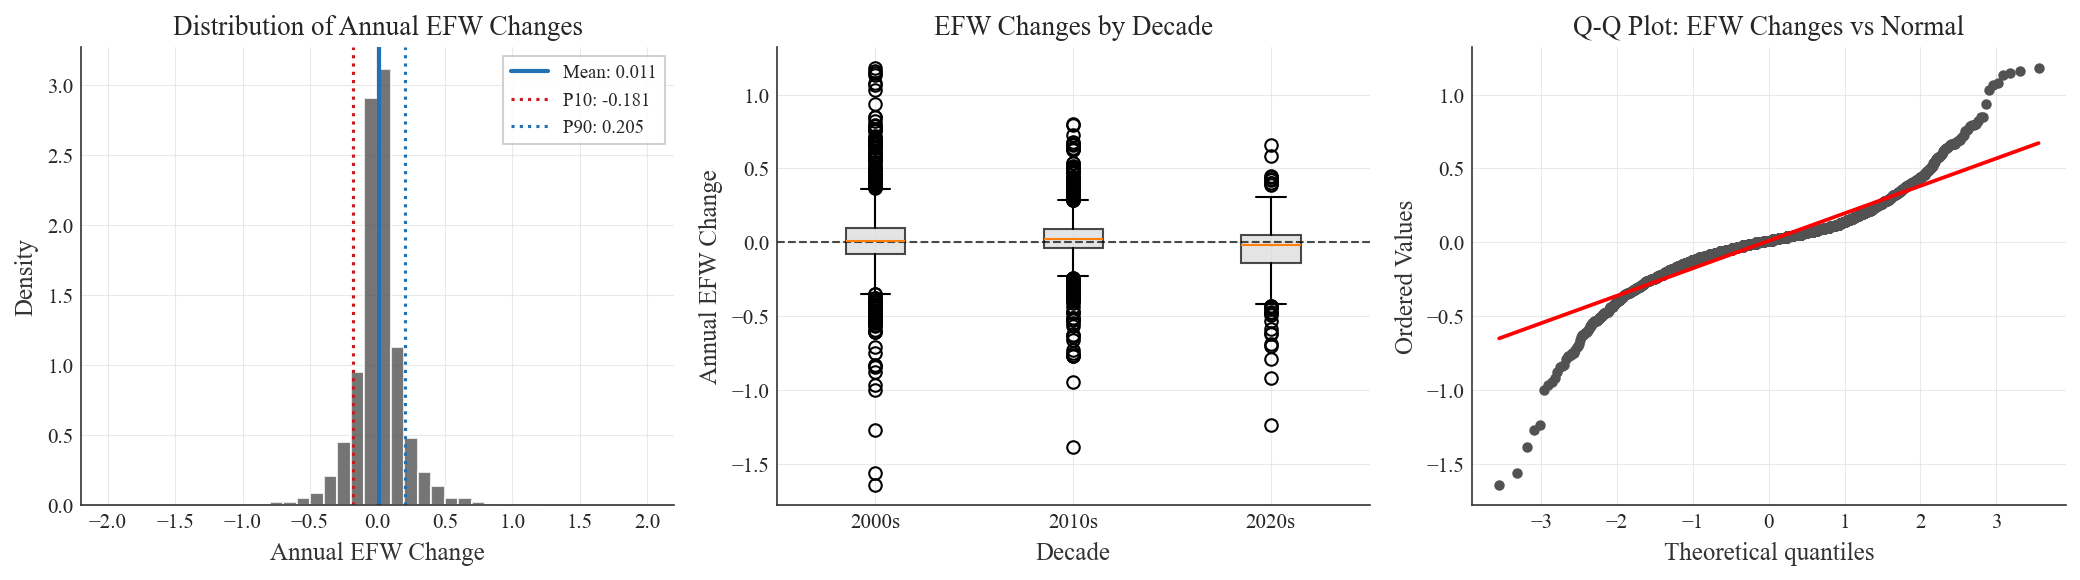


### Event Classification (Threshold-based)
Large increases (Δ ≥ 0.5): 61 events
Large decreases (Δ ≤ -0.5): 50 events
Moderate increases (0.3 ≤ Δ < 0.5): 140 events
Moderate decreases (-0.5 < Δ ≤ -0.3): 109 events


,Change Type,Count,Percent
0,stable,2228,42.7803
1,missing,1507,28.9363
2,small_increase,596,11.4439
3,small_decrease,517,9.9270
4,moderate_increase,140,2.6882
5,moderate_decrease,109,2.0929
6,large_increase,61,1.1713
7,large_decrease,50,0.9601


In [6]:
# =============================================================================
# Section 4: EFW Change Distribution and Event Identification
# =============================================================================

display(Markdown("""
## EFW Change Distribution Analysis

Understanding the distribution of EFW changes is crucial for:
1. Identifying meaningful reform episodes
2. Distinguishing signal from noise in annual fluctuations
3. Selecting appropriate thresholds for event studies
"""))

# Analyze EFW change distribution
efw_changes = panel['efw_delta_1y'].dropna()
print(f"Total EFW annual changes: {len(efw_changes):,}")
print(f"Mean change: {efw_changes.mean():.4f}")
print(f"Std of changes: {efw_changes.std():.4f}")
print(f"Skewness: {efw_changes.skew():.4f}")
print(f"Kurtosis: {efw_changes.kurtosis():.4f}")

# Distribution plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogram
ax = axes[0]
bins = np.arange(-2, 2.1, 0.1)
ax.hist(efw_changes, bins=bins, color=COLORS['neutral'], edgecolor='white', alpha=0.8, density=True)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(efw_changes.mean(), color=COLORS['increase'], linestyle='-', linewidth=2, label=f'Mean: {efw_changes.mean():.3f}')
ax.axvline(efw_changes.quantile(0.10), color=COLORS['decrease'], linestyle=':', linewidth=1.5, label=f'P10: {efw_changes.quantile(0.10):.3f}')
ax.axvline(efw_changes.quantile(0.90), color=COLORS['increase'], linestyle=':', linewidth=1.5, label=f'P90: {efw_changes.quantile(0.90):.3f}')
ax.set_xlabel('Annual EFW Change')
ax.set_ylabel('Density')
ax.set_title('Distribution of Annual EFW Changes')
ax.legend(loc='upper right', fontsize=9)

# Box plot by decade
ax = axes[1]
panel['decade'] = (panel['year'] // 10) * 10
decade_data = panel[panel['efw_delta_1y'].notna()]
decades = sorted(decade_data['decade'].unique())
bp_data = [decade_data[decade_data['decade'] == d]['efw_delta_1y'].values for d in decades]
bp = ax.boxplot(bp_data, labels=[str(d)+'s' for d in decades], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(COLORS['ci_fill'])
    patch.set_alpha(0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Decade')
ax.set_ylabel('Annual EFW Change')
ax.set_title('EFW Changes by Decade')

# Q-Q plot to assess normality
ax = axes[2]
stats.probplot(efw_changes, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: EFW Changes vs Normal')
ax.get_lines()[0].set_markerfacecolor(COLORS['neutral'])
ax.get_lines()[0].set_markeredgecolor(COLORS['neutral'])
ax.get_lines()[0].set_markersize(4)

plt.tight_layout()
save_fig('efw_change_distribution')
plt.show()

# =============================================================================
# Define Event Categories Based on EFW Changes
# =============================================================================

# Thresholds based on distribution (using percentiles for robustness)
THRESHOLD_LARGE = 0.5     # Approximately P90 for increases
THRESHOLD_MODERATE = 0.3  # Approximately P75
THRESHOLD_SMALL = 0.1     # Minimal meaningful change

# Count events
n_large_increase = (panel['efw_delta_1y'] >= THRESHOLD_LARGE).sum()
n_large_decrease = (panel['efw_delta_1y'] <= -THRESHOLD_LARGE).sum()
n_moderate_increase = ((panel['efw_delta_1y'] >= THRESHOLD_MODERATE) & (panel['efw_delta_1y'] < THRESHOLD_LARGE)).sum()
n_moderate_decrease = ((panel['efw_delta_1y'] <= -THRESHOLD_MODERATE) & (panel['efw_delta_1y'] > -THRESHOLD_LARGE)).sum()

print(f"\n### Event Classification (Threshold-based)")
print(f"Large increases (Δ ≥ {THRESHOLD_LARGE}): {n_large_increase:,} events")
print(f"Large decreases (Δ ≤ -{THRESHOLD_LARGE}): {n_large_decrease:,} events")
print(f"Moderate increases ({THRESHOLD_MODERATE} ≤ Δ < {THRESHOLD_LARGE}): {n_moderate_increase:,} events")
print(f"Moderate decreases (-{THRESHOLD_LARGE} < Δ ≤ -{THRESHOLD_MODERATE}): {n_moderate_decrease:,} events")

# Create event type variable
def classify_efw_change(delta):
    if pd.isna(delta):
        return 'missing'
    elif delta >= THRESHOLD_LARGE:
        return 'large_increase'
    elif delta <= -THRESHOLD_LARGE:
        return 'large_decrease'
    elif delta >= THRESHOLD_MODERATE:
        return 'moderate_increase'
    elif delta <= -THRESHOLD_MODERATE:
        return 'moderate_decrease'
    elif delta >= THRESHOLD_SMALL:
        return 'small_increase'
    elif delta <= -THRESHOLD_SMALL:
        return 'small_decrease'
    else:
        return 'stable'

panel['efw_change_type'] = panel['efw_delta_1y'].apply(classify_efw_change)

# Summary of event types
event_summary = panel['efw_change_type'].value_counts().reset_index()
event_summary.columns = ['Change Type', 'Count']
event_summary['Percent'] = event_summary['Count'] / event_summary['Count'].sum() * 100
save_table(event_summary, 'efw_change_type_distribution')
display(event_summary)

## Section 5: Trajectory Analysis Framework

### Methodological Approach

We examine how macroeconomic outcomes evolve around EFW change events using an event-study design:

$$Y_{i,t+k} - Y_{i,t-1} = f(k, \Delta EFW_{it})$$

where:
- $k \in \{-4, -3, ..., 0, 1, 2, 3, 4\}$ is the event time
- $t$ is the year of the EFW change event
- Outcomes are **normalized to $k=-1$** (pre-event level)

This design reveals:
1. **Pre-trends**: Are macro outcomes already changing before EFW moves?
2. **Immediate response**: How do outcomes shift in the year of the change?
3. **Persistence**: Do effects accumulate or dissipate over time?

### Key Statistical Considerations

1. **Selection bias**: Countries that experience EFW changes may differ systematically
2. **Reverse causality**: Macro shocks may cause EFW changes
3. **Heterogeneous effects**: Effects may vary by country characteristics

We address these through:
- Comparing EFW increases vs. decreases (asymmetry analysis)
- Stratifying by initial conditions (state-dependence)
- Bootstrap confidence intervals for uncertainty quantification

In [7]:
# =============================================================================
# Section 5: Event-Time Dataset Construction
# =============================================================================

def build_event_time_dataset(
    panel: pd.DataFrame,
    event_condition: pd.Series,
    k_range: tuple = (-4, 4),
    normalize_to: int = -1,
    outcome_vars: list = None,
) -> pd.DataFrame:
    """
    Build an event-time dataset for trajectory analysis.
    
    Parameters:
    -----------
    panel : DataFrame with iso3, year, and outcome variables
    event_condition : Boolean Series identifying event observations
    k_range : Tuple (min_k, max_k) for event time window
    normalize_to : Event time k at which to normalize outcomes (typically -1)
    outcome_vars : List of outcome variables to include
    
    Returns:
    --------
    DataFrame with columns: iso3, event_year, year, k, and outcome variables
    """
    if outcome_vars is None:
        outcome_vars = [c for c in panel.columns if c.startswith(('pwt_', 'wdi_')) 
                       and not c.endswith('_log') or c in ['pwt_gdp_pc_log', 'pwt_tfp_log',
                       'pwt_capital_stock_log', 'pwt_output_per_worker_log', 'pwt_human_capital_log']]
    
    k_min, k_max = k_range
    k_vals = list(range(k_min, k_max + 1))
    
    # Get event observations
    events = panel[event_condition][['iso3', 'year']].copy()
    events = events.rename(columns={'year': 'event_year'})
    
    # Build event-time rows
    rows = []
    for _, event in events.iterrows():
        iso3, event_year = event['iso3'], event['event_year']
        for k in k_vals:
            rows.append({
                'iso3': iso3,
                'event_year': int(event_year),
                'year': int(event_year) + k,
                'k': k,
            })
    
    et = pd.DataFrame(rows)
    
    # Merge outcomes
    merge_cols = ['iso3', 'year'] + [v for v in outcome_vars if v in panel.columns]
    merge_cols += ['efw', 'efw_delta_1y', 'efw_initial']
    merge_cols = list(set(merge_cols))
    et = et.merge(panel[merge_cols], on=['iso3', 'year'], how='left')
    
    # Get normalization values (at k = normalize_to)
    norm_df = et[et['k'] == normalize_to][['iso3', 'event_year'] + outcome_vars].copy()
    norm_df = norm_df.rename(columns={v: f'{v}_norm' for v in outcome_vars})
    et = et.merge(norm_df, on=['iso3', 'event_year'], how='left')
    
    # Compute normalized outcomes (difference from baseline)
    for v in outcome_vars:
        if v in et.columns and f'{v}_norm' in et.columns:
            et[f'{v}_diff'] = et[v] - et[f'{v}_norm']
    
    return et


# Build event-time datasets for different EFW change thresholds
OUTCOME_VARS_ANALYSIS = [
    'pwt_gdp_pc_log', 'pwt_tfp', 'pwt_human_capital', 
    'pwt_capital_stock_log', 'pwt_output_per_worker_log',
    'pwt_consumption_share', 'pwt_investment_share', 'pwt_government_share',
    'pwt_exports_share', 'pwt_imports_share', 'pwt_irr',
    'wdi_gdp_growth', 'wdi_gdp_pc_growth', 'wdi_inflation',
]
OUTCOME_VARS_ANALYSIS = [v for v in OUTCOME_VARS_ANALYSIS if v in panel.columns]

# Large EFW increases (Δ ≥ 0.5)
et_large_increase = build_event_time_dataset(
    panel,
    event_condition=(panel['efw_delta_1y'] >= THRESHOLD_LARGE),
    outcome_vars=OUTCOME_VARS_ANALYSIS,
)
et_large_increase['event_type'] = 'large_increase'
print(f"Large increases: {et_large_increase['event_year'].nunique()} events, {len(et_large_increase)} obs")

# Large EFW decreases (Δ ≤ -0.5)
et_large_decrease = build_event_time_dataset(
    panel,
    event_condition=(panel['efw_delta_1y'] <= -THRESHOLD_LARGE),
    outcome_vars=OUTCOME_VARS_ANALYSIS,
)
et_large_decrease['event_type'] = 'large_decrease'
print(f"Large decreases: {et_large_decrease['event_year'].nunique()} events, {len(et_large_decrease)} obs")

# Moderate increases (0.3 ≤ Δ < 0.5)
et_moderate_increase = build_event_time_dataset(
    panel,
    event_condition=((panel['efw_delta_1y'] >= THRESHOLD_MODERATE) & (panel['efw_delta_1y'] < THRESHOLD_LARGE)),
    outcome_vars=OUTCOME_VARS_ANALYSIS,
)
et_moderate_increase['event_type'] = 'moderate_increase'
print(f"Moderate increases: {et_moderate_increase['event_year'].nunique()} events, {len(et_moderate_increase)} obs")

# Moderate decreases (-0.5 < Δ ≤ -0.3)
et_moderate_decrease = build_event_time_dataset(
    panel,
    event_condition=((panel['efw_delta_1y'] <= -THRESHOLD_MODERATE) & (panel['efw_delta_1y'] > -THRESHOLD_LARGE)),
    outcome_vars=OUTCOME_VARS_ANALYSIS,
)
et_moderate_decrease['event_type'] = 'moderate_decrease'
print(f"Moderate decreases: {et_moderate_decrease['event_year'].nunique()} events, {len(et_moderate_decrease)} obs")

# Combined event-time dataset
et_combined = pd.concat([
    et_large_increase, et_large_decrease,
    et_moderate_increase, et_moderate_decrease
], ignore_index=True)

print(f"\nTotal event-time observations: {len(et_combined):,}")
save_table(
    et_combined.groupby('event_type').agg(
        n_events=('event_year', 'nunique'),
        n_countries=('iso3', 'nunique'),
        mean_delta=('efw_delta_1y', lambda x: x[x.index.isin(et_combined[et_combined['k']==0].index)].mean() if len(x) > 0 else np.nan)
    ).reset_index(),
    'event_time_summary'
)

Large increases: 21 events, 549 obs
Large decreases: 20 events, 450 obs
Moderate increases: 22 events, 1260 obs
Moderate decreases: 23 events, 981 obs

Total event-time observations: 3,240


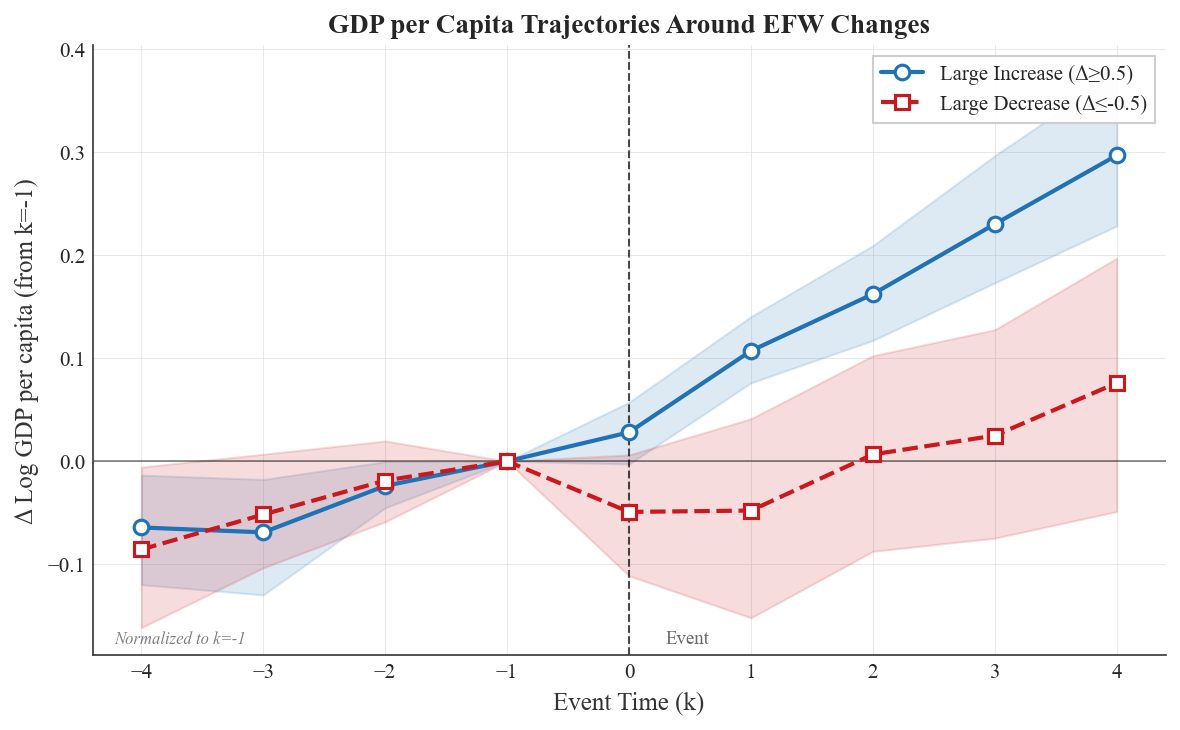

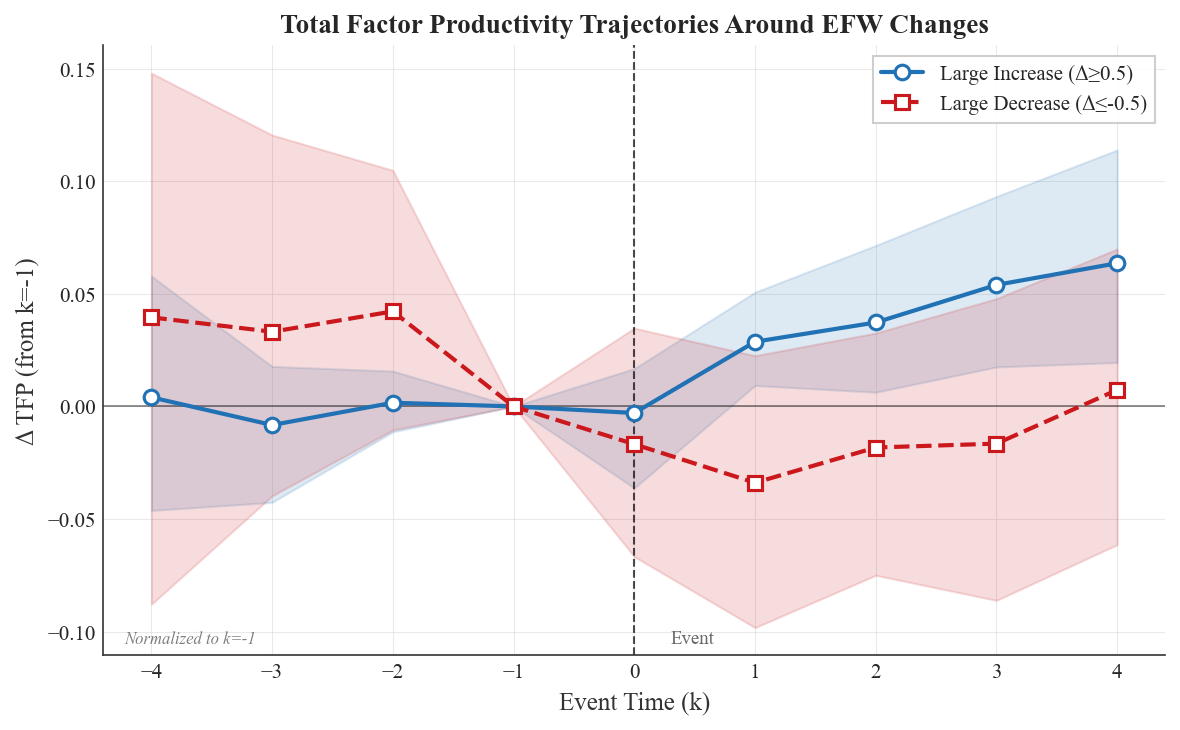

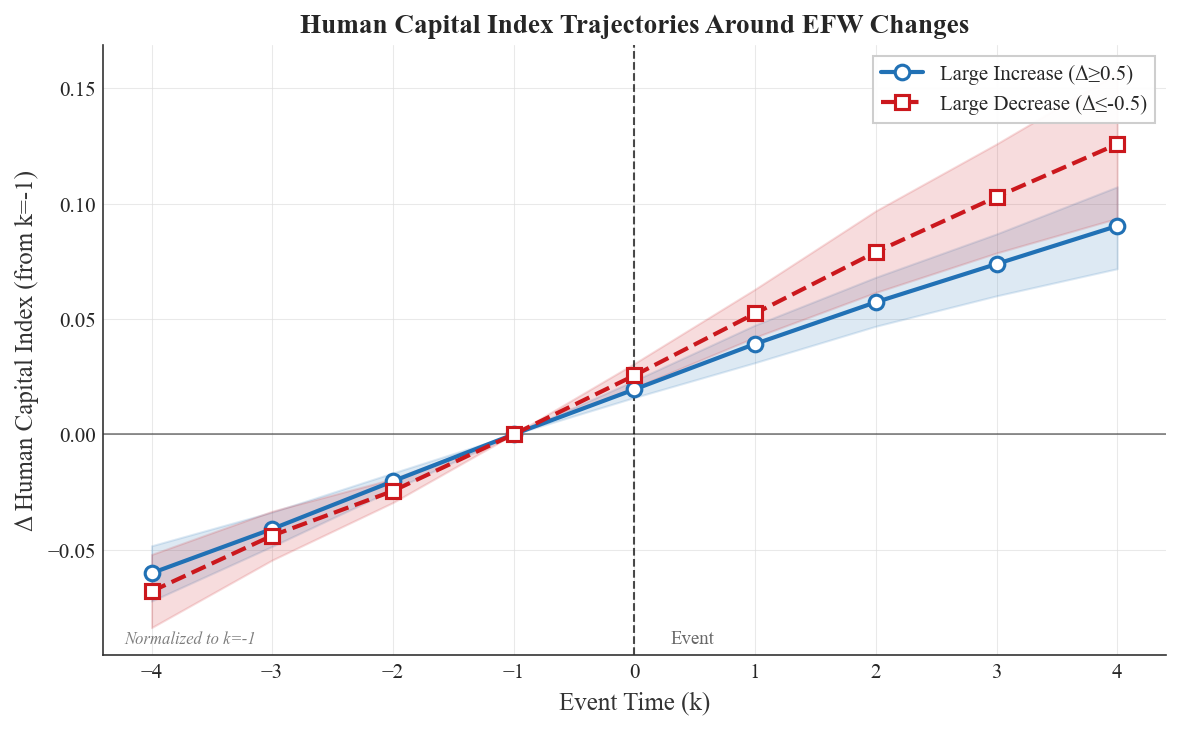

In [8]:
# =============================================================================
# Section 6: Core Trajectory Visualizations
# =============================================================================

def plot_event_time_trajectory(
    et_data: pd.DataFrame,
    outcome_var: str,
    title: str,
    ylabel: str,
    groups: dict = None,
    normalized: bool = True,
    show_ci: bool = True,
    ci_level: float = 0.95,
    figsize: tuple = (8, 5),
    ylim: tuple = None,
) -> plt.Figure:
    """
    Create publication-quality event-time trajectory plot.
    
    Parameters:
    -----------
    et_data : Event-time DataFrame
    outcome_var : Variable to plot (will use {var}_diff if normalized=True)
    title : Plot title
    ylabel : Y-axis label
    groups : Dict mapping group_name -> boolean mask or event_type values
    normalized : Whether to use normalized (differenced) outcomes
    show_ci : Whether to show confidence intervals
    ci_level : Confidence interval level (default 95%)
    figsize : Figure size
    ylim : Y-axis limits (optional)
    
    Returns:
    --------
    matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    var_to_plot = f'{outcome_var}_diff' if normalized and f'{outcome_var}_diff' in et_data.columns else outcome_var
    
    if groups is None:
        groups = {'All Events': et_data['k'].notna()}
    
    line_styles = ['-', '--', ':', '-.']
    markers = ['o', 's', '^', 'D']
    
    for i, (label, condition) in enumerate(groups.items()):
        if isinstance(condition, str):
            subset = et_data[et_data['event_type'] == condition]
        else:
            subset = et_data[condition]
        
        # Compute mean and CI by k
        stats_by_k = []
        for k in sorted(subset['k'].unique()):
            k_data = subset[subset['k'] == k][var_to_plot].dropna()
            if len(k_data) >= 3:
                mean_val = k_data.mean()
                lo, hi = bootstrap_ci(k_data.values, ci=ci_level)
                stats_by_k.append({'k': k, 'mean': mean_val, 'ci_lo': lo, 'ci_hi': hi, 'n': len(k_data)})
        
        if not stats_by_k:
            continue
            
        stats_df = pd.DataFrame(stats_by_k)
        
        # Determine color based on label
        if 'increase' in label.lower():
            color = COLORS['increase']
        elif 'decrease' in label.lower():
            color = COLORS['decrease']
        else:
            color = COLORS['neutral']
        
        # Plot line with markers
        ax.plot(stats_df['k'], stats_df['mean'], 
                color=color, linestyle=line_styles[i % len(line_styles)],
                marker=markers[i % len(markers)], markersize=7, markerfacecolor='white',
                markeredgewidth=1.5, linewidth=2, label=label, zorder=3)
        
        # Confidence interval
        if show_ci:
            ax.fill_between(stats_df['k'], stats_df['ci_lo'], stats_df['ci_hi'],
                          color=color, alpha=0.15, zorder=1)
    
    # Reference lines
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5, zorder=2)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=2)
    
    # Annotations
    ax.annotate('Event', xy=(0, ax.get_ylim()[0]), xytext=(0.3, ax.get_ylim()[0] + 0.02*(ax.get_ylim()[1]-ax.get_ylim()[0])),
               fontsize=9, alpha=0.7)
    
    # Labels and formatting
    ax.set_xlabel('Event Time (k)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    
    if ylim:
        ax.set_ylim(ylim)
    
    ax.set_xticks(range(-4, 5))
    ax.legend(loc='best', framealpha=0.95)
    
    # Add subtle annotation about normalization
    if normalized:
        ax.text(0.02, 0.02, 'Normalized to k=-1', transform=ax.transAxes, 
               fontsize=8, alpha=0.6, style='italic')
    
    plt.tight_layout()
    return fig


# =============================================================================
# Plot 1: Log GDP per Capita Trajectories
# =============================================================================

fig = plot_event_time_trajectory(
    et_combined,
    outcome_var='pwt_gdp_pc_log',
    title='GDP per Capita Trajectories Around EFW Changes',
    ylabel='Δ Log GDP per capita (from k=-1)',
    groups={
        'Large Increase (Δ≥0.5)': 'large_increase',
        'Large Decrease (Δ≤-0.5)': 'large_decrease',
    },
    normalized=True,
)
save_fig('trajectory_gdp_pc_log')
plt.show()

# =============================================================================
# Plot 2: TFP Trajectories
# =============================================================================

fig = plot_event_time_trajectory(
    et_combined,
    outcome_var='pwt_tfp',
    title='Total Factor Productivity Trajectories Around EFW Changes',
    ylabel='Δ TFP (from k=-1)',
    groups={
        'Large Increase (Δ≥0.5)': 'large_increase',
        'Large Decrease (Δ≤-0.5)': 'large_decrease',
    },
    normalized=True,
)
save_fig('trajectory_tfp')
plt.show()

# =============================================================================
# Plot 3: Human Capital Trajectories
# =============================================================================

fig = plot_event_time_trajectory(
    et_combined,
    outcome_var='pwt_human_capital',
    title='Human Capital Index Trajectories Around EFW Changes',
    ylabel='Δ Human Capital Index (from k=-1)',
    groups={
        'Large Increase (Δ≥0.5)': 'large_increase',
        'Large Decrease (Δ≤-0.5)': 'large_decrease',
    },
    normalized=True,
)
save_fig('trajectory_human_capital')
plt.show()

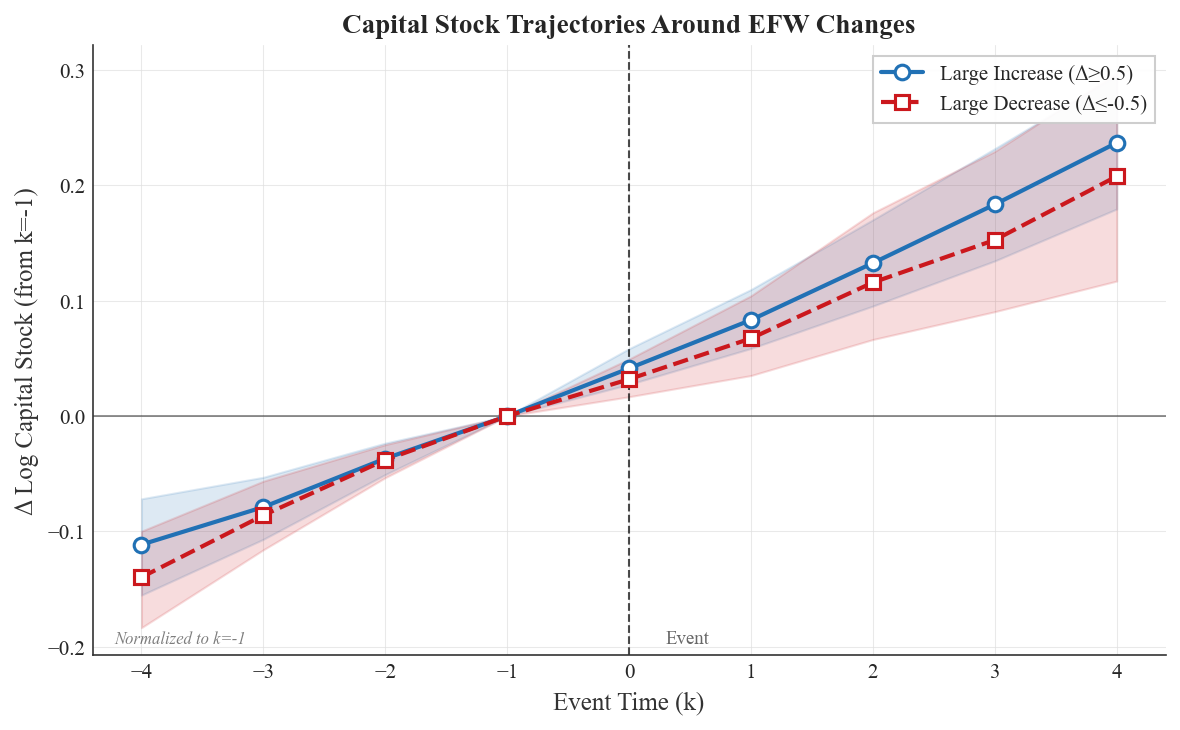

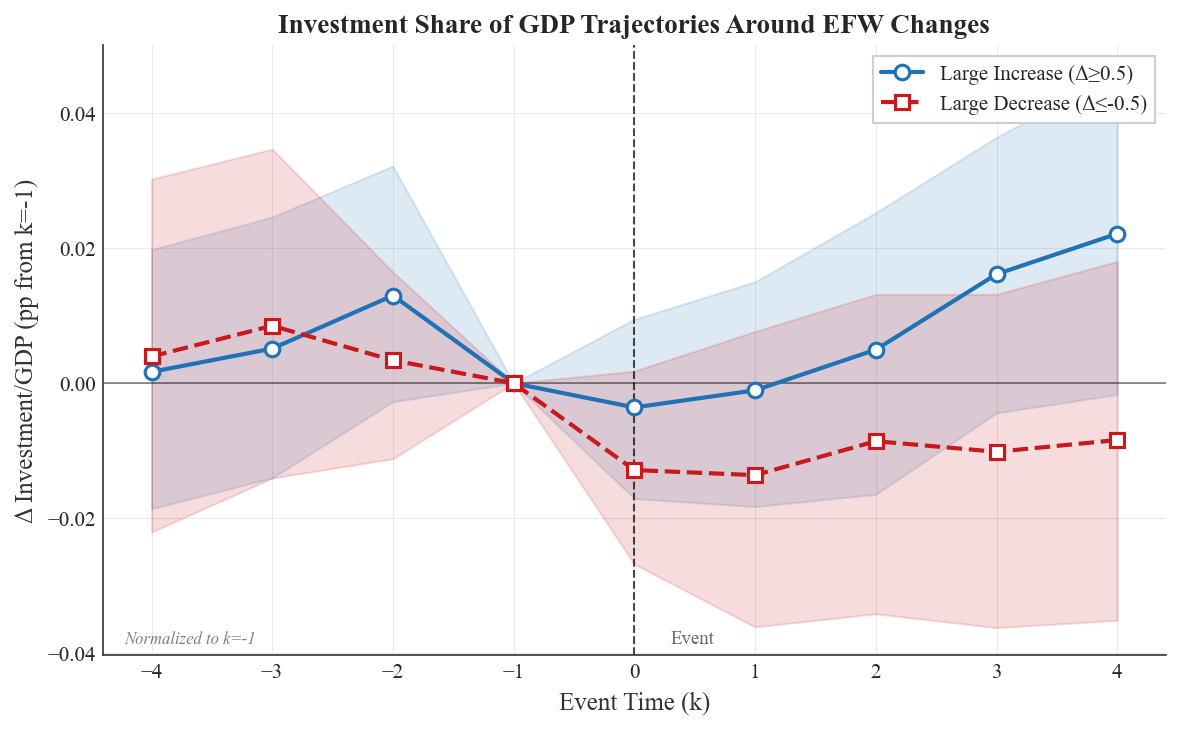

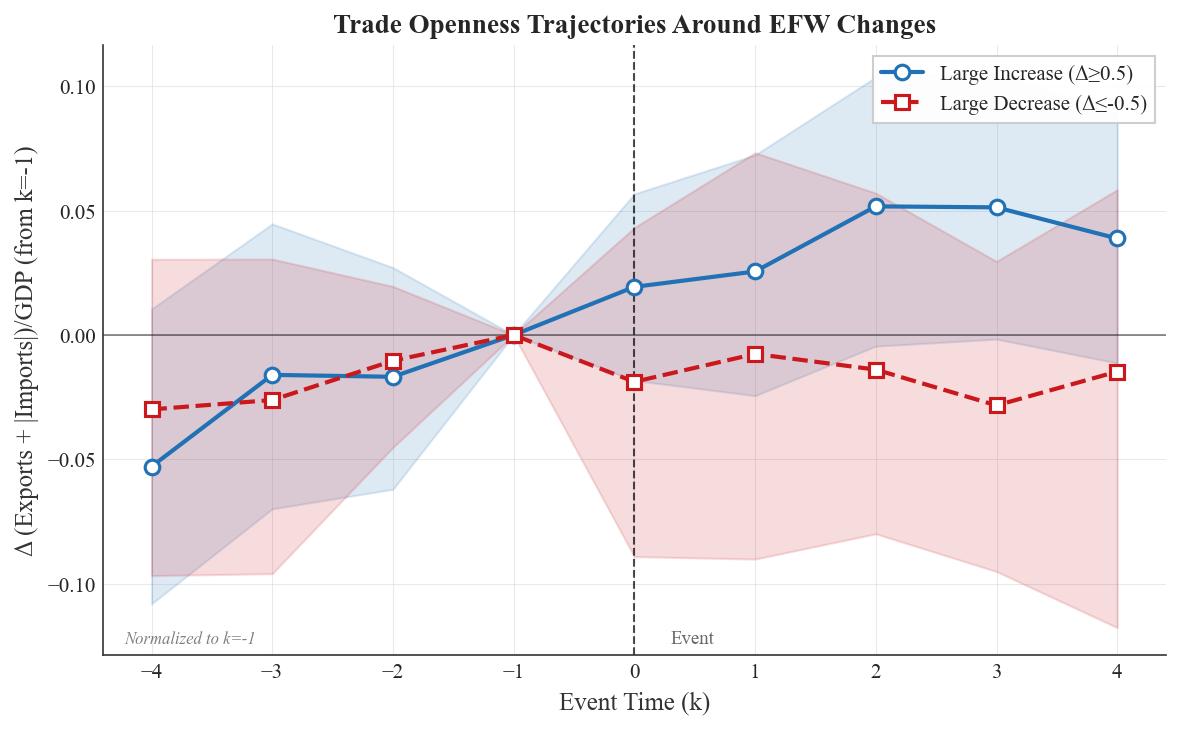

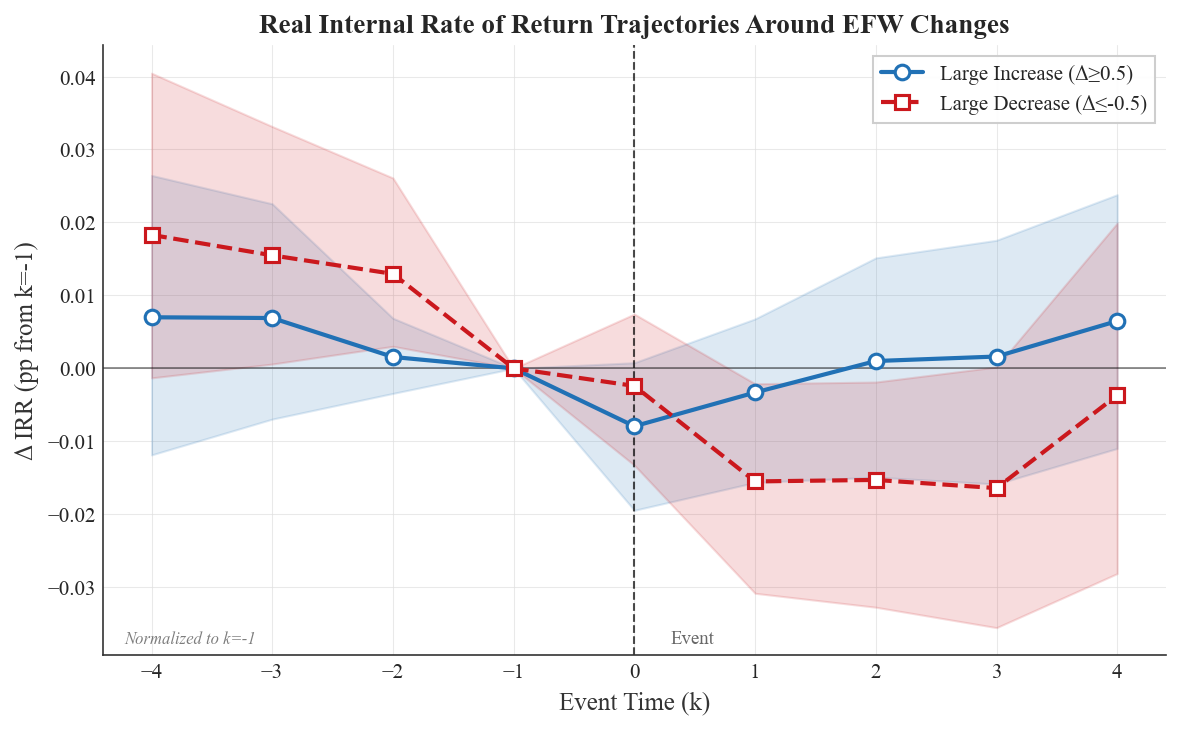

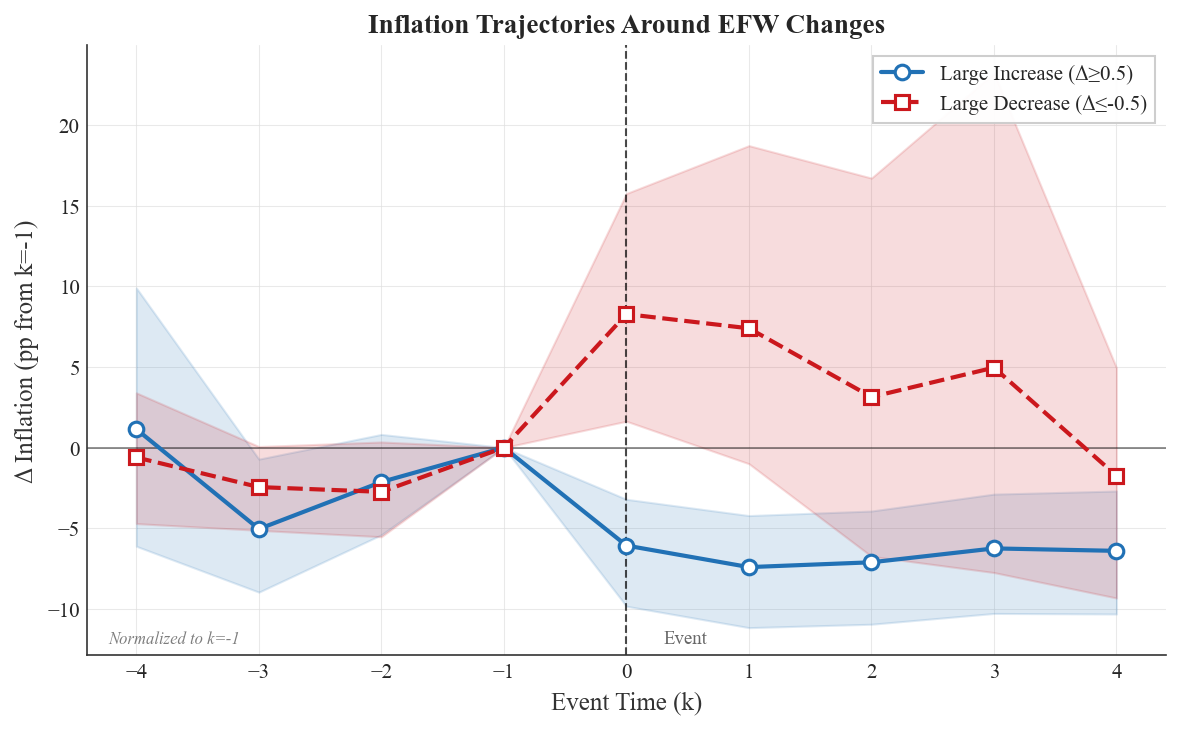

In [9]:
# =============================================================================
# Section 6 (continued): Additional Trajectory Plots
# =============================================================================

# =============================================================================
# Plot 4: Capital Stock Trajectories
# =============================================================================

fig = plot_event_time_trajectory(
    et_combined,
    outcome_var='pwt_capital_stock_log',
    title='Capital Stock Trajectories Around EFW Changes',
    ylabel='Δ Log Capital Stock (from k=-1)',
    groups={
        'Large Increase (Δ≥0.5)': 'large_increase',
        'Large Decrease (Δ≤-0.5)': 'large_decrease',
    },
    normalized=True,
)
save_fig('trajectory_capital_stock')
plt.show()

# =============================================================================
# Plot 5: Investment Share Trajectories
# =============================================================================

fig = plot_event_time_trajectory(
    et_combined,
    outcome_var='pwt_investment_share',
    title='Investment Share of GDP Trajectories Around EFW Changes',
    ylabel='Δ Investment/GDP (pp from k=-1)',
    groups={
        'Large Increase (Δ≥0.5)': 'large_increase',
        'Large Decrease (Δ≤-0.5)': 'large_decrease',
    },
    normalized=True,
)
save_fig('trajectory_investment_share')
plt.show()

# =============================================================================
# Plot 6: Trade Openness (Exports + Imports shares)
# =============================================================================

# Create combined trade variable
et_combined['pwt_trade_share'] = et_combined['pwt_exports_share'].abs() + et_combined['pwt_imports_share'].abs()
et_norm_trade = et_combined[et_combined['k'] == -1][['iso3', 'event_year', 'pwt_trade_share']].copy()
et_norm_trade = et_norm_trade.rename(columns={'pwt_trade_share': 'pwt_trade_share_norm'})
et_combined = et_combined.merge(et_norm_trade, on=['iso3', 'event_year'], how='left')
et_combined['pwt_trade_share_diff'] = et_combined['pwt_trade_share'] - et_combined['pwt_trade_share_norm']

fig = plot_event_time_trajectory(
    et_combined,
    outcome_var='pwt_trade_share',
    title='Trade Openness Trajectories Around EFW Changes',
    ylabel='Δ (Exports + |Imports|)/GDP (from k=-1)',
    groups={
        'Large Increase (Δ≥0.5)': 'large_increase',
        'Large Decrease (Δ≤-0.5)': 'large_decrease',
    },
    normalized=True,
)
save_fig('trajectory_trade_openness')
plt.show()

# =============================================================================
# Plot 7: Internal Rate of Return
# =============================================================================

fig = plot_event_time_trajectory(
    et_combined,
    outcome_var='pwt_irr',
    title='Real Internal Rate of Return Trajectories Around EFW Changes',
    ylabel='Δ IRR (pp from k=-1)',
    groups={
        'Large Increase (Δ≥0.5)': 'large_increase',
        'Large Decrease (Δ≤-0.5)': 'large_decrease',
    },
    normalized=True,
)
save_fig('trajectory_irr')
plt.show()

# =============================================================================
# Plot 8: Inflation (WDI fallback)
# =============================================================================

if 'wdi_inflation' in OUTCOME_VARS_ANALYSIS:
    fig = plot_event_time_trajectory(
        et_combined,
        outcome_var='wdi_inflation',
        title='Inflation Trajectories Around EFW Changes',
        ylabel='Δ Inflation (pp from k=-1)',
        groups={
            'Large Increase (Δ≥0.5)': 'large_increase',
            'Large Decrease (Δ≤-0.5)': 'large_decrease',
        },
        normalized=True,
    )
    save_fig('trajectory_inflation')
    plt.show()

## Section 7: Asymmetry Analysis

### Economic Intuition

A fundamental question in reform economics is whether policy changes have **symmetric effects**:

1. **Symmetric view**: An improvement of +0.5 in EFW should have the mirror effect of a decline of -0.5
2. **Asymmetric view**: Reforms and reversals may have different magnitudes due to:
   - **Hysteresis**: Capital destruction during crises is faster than capital accumulation
   - **Expectations**: Uncertainty about reform durability dampens positive effects
   - **Political economy**: Losers from reform may resist more than winners support

### Statistical Framework

We test for asymmetry by comparing:
$$E[Y_{i,t+k} - Y_{i,t-1} | \Delta EFW \geq \tau] \stackrel{?}{=} -E[Y_{i,t+k} - Y_{i,t-1} | \Delta EFW \leq -\tau]$$

We use:
1. **Visual inspection** of trajectory divergence
2. **Formal hypothesis tests** (t-tests, Mann-Whitney)
3. **Effect size measures** (Cohen's d)

### Asymmetry Test Results at k=3 (3 years post-event)

,variable,mean_increase,mean_decrease,asymmetry_gap,t_pvalue,cohen_d
7,Log GDP per capita,0.2299,0.0249,0.2547,0.0001,0.8914
16,TFP,0.0540,-0.0165,0.0375,0.3475,0.2743
25,Log Capital Stock,0.1834,0.1526,0.3360,0.0000,1.8455
34,Investment/GDP,0.0162,-0.0102,0.0060,0.7148,0.0753
43,Human Capital,0.0739,0.1029,0.1768,0.0000,3.1346
52,GDP Growth,3.4286,2.7933,6.2219,0.0312,0.4702


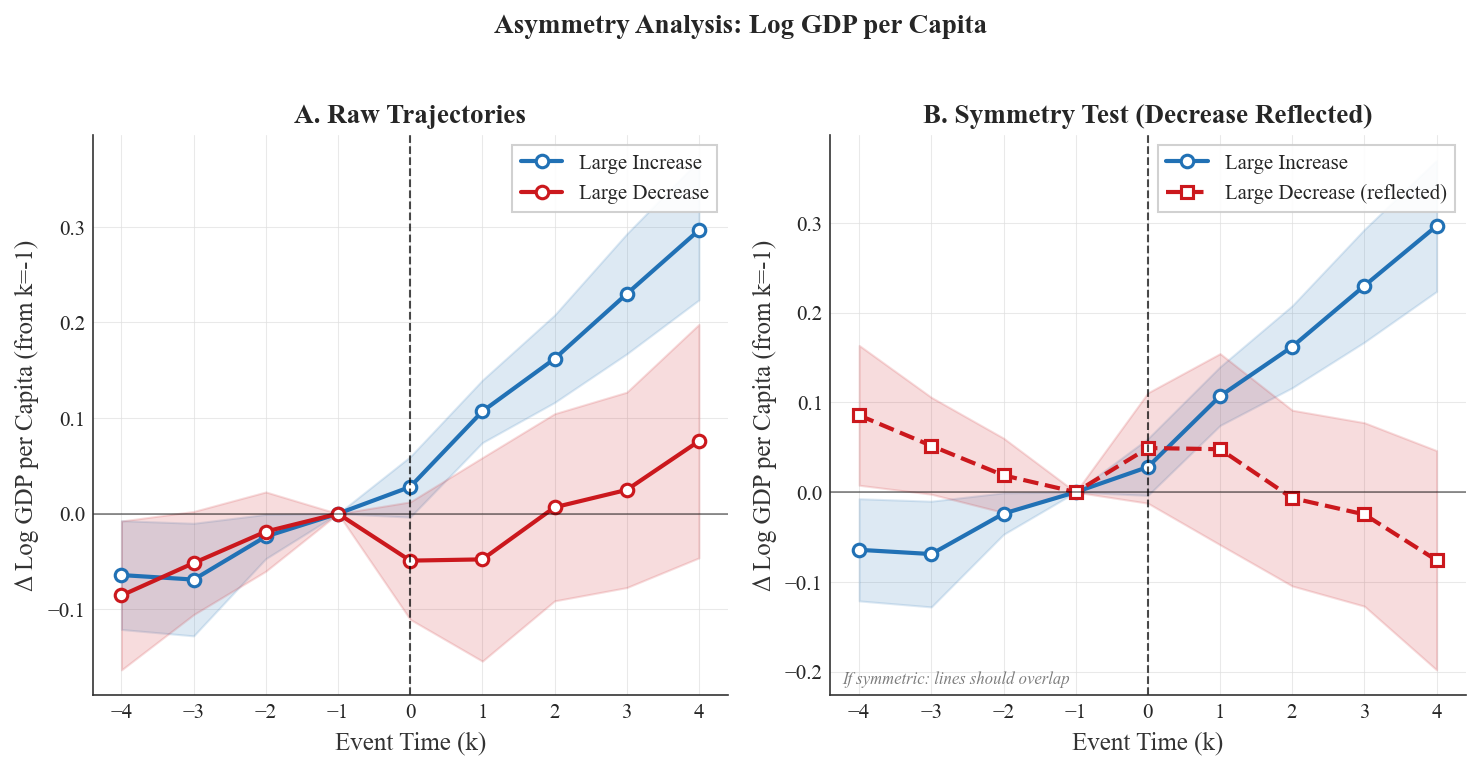

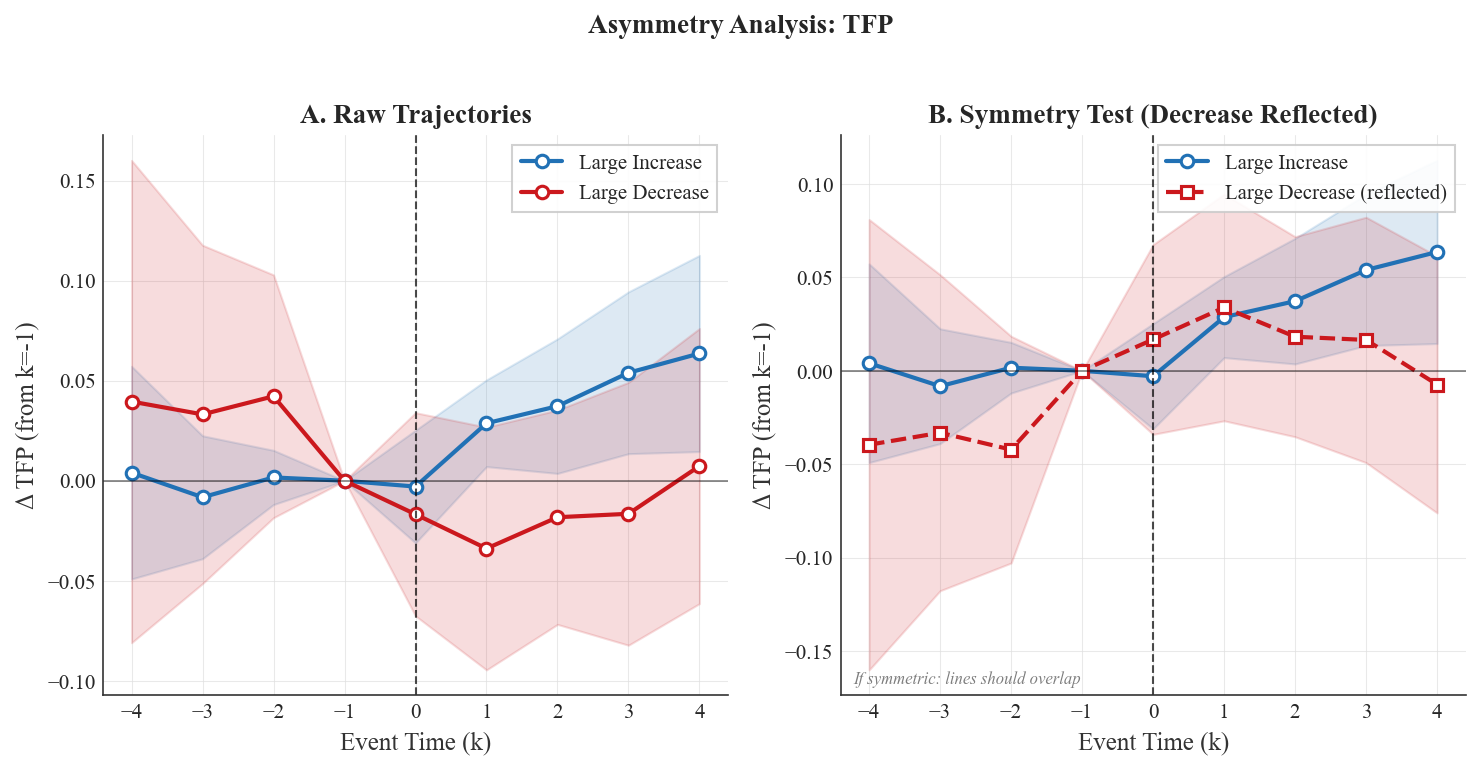

In [10]:
# =============================================================================
# Section 7: Formal Asymmetry Tests
# =============================================================================

def compute_asymmetry_stats(
    et_data: pd.DataFrame,
    outcome_var: str,
    k_horizon: int = 3,
) -> pd.DataFrame:
    """
    Compute asymmetry statistics comparing increases vs. decreases.
    
    Tests whether |effect of increase| = |effect of decrease|
    """
    var_diff = f'{outcome_var}_diff'
    if var_diff not in et_data.columns:
        return pd.DataFrame()
    
    results = []
    
    for k in range(-4, k_horizon + 1):
        # Get data for each group at this k
        inc_data = et_data[(et_data['event_type'] == 'large_increase') & (et_data['k'] == k)][var_diff].dropna()
        dec_data = et_data[(et_data['event_type'] == 'large_decrease') & (et_data['k'] == k)][var_diff].dropna()
        
        if len(inc_data) < 5 or len(dec_data) < 5:
            continue
        
        # For asymmetry test, we compare inc_data with -dec_data
        # (if symmetric, mean(inc) ≈ -mean(dec))
        dec_reflected = -dec_data
        
        # T-test for difference
        t_stat, t_pval = ttest_ind(inc_data, dec_reflected, equal_var=False)
        
        # Mann-Whitney (non-parametric)
        try:
            mw_stat, mw_pval = mannwhitneyu(inc_data, dec_reflected, alternative='two-sided')
        except:
            mw_stat, mw_pval = np.nan, np.nan
        
        # Effect size
        d = cohen_d(inc_data.values, dec_reflected.values)
        
        results.append({
            'k': k,
            'n_increase': len(inc_data),
            'n_decrease': len(dec_data),
            'mean_increase': inc_data.mean(),
            'mean_decrease': dec_data.mean(),
            'mean_decrease_reflected': dec_reflected.mean(),
            'asymmetry_gap': inc_data.mean() - dec_reflected.mean(),
            't_statistic': t_stat,
            't_pvalue': t_pval,
            'mw_pvalue': mw_pval,
            'cohen_d': d,
            'asymmetric_5pct': t_pval < 0.05,
        })
    
    return pd.DataFrame(results)


# Compute asymmetry for key outcomes
ASYMMETRY_OUTCOMES = [
    ('pwt_gdp_pc_log', 'Log GDP per capita'),
    ('pwt_tfp', 'TFP'),
    ('pwt_capital_stock_log', 'Log Capital Stock'),
    ('pwt_investment_share', 'Investment/GDP'),
    ('pwt_human_capital', 'Human Capital'),
    ('wdi_gdp_growth', 'GDP Growth'),
]

asymmetry_results = []
for var, label in ASYMMETRY_OUTCOMES:
    if var not in OUTCOME_VARS_ANALYSIS:
        continue
    df = compute_asymmetry_stats(et_combined, var, k_horizon=4)
    if not df.empty:
        df['variable'] = label
        asymmetry_results.append(df)

if asymmetry_results:
    asymmetry_df = pd.concat(asymmetry_results, ignore_index=True)
    save_table(asymmetry_df, 'asymmetry_test_results')
    
    # Display summary at k=3 (medium-term horizon)
    display(Markdown("### Asymmetry Test Results at k=3 (3 years post-event)"))
    summary_k3 = asymmetry_df[asymmetry_df['k'] == 3][
        ['variable', 'mean_increase', 'mean_decrease', 'asymmetry_gap', 't_pvalue', 'cohen_d']
    ].round(4)
    display(summary_k3)

# =============================================================================
# Visualization: Asymmetry Comparison
# =============================================================================

def plot_asymmetry_comparison(
    et_data: pd.DataFrame,
    outcome_var: str,
    title: str,
    ylabel: str,
    figsize: tuple = (10, 5),
) -> plt.Figure:
    """
    Create side-by-side plot comparing increase trajectories with reflected decrease trajectories.
    """
    var_diff = f'{outcome_var}_diff'
    if var_diff not in et_data.columns:
        return None
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Left panel: Raw trajectories
    ax = axes[0]
    for event_type, color, label in [
        ('large_increase', COLORS['increase'], 'Large Increase'),
        ('large_decrease', COLORS['decrease'], 'Large Decrease'),
    ]:
        subset = et_data[et_data['event_type'] == event_type]
        stats_by_k = subset.groupby('k')[var_diff].agg(['mean', 'std', 'count']).reset_index()
        stats_by_k['se'] = stats_by_k['std'] / np.sqrt(stats_by_k['count'])
        
        ax.plot(stats_by_k['k'], stats_by_k['mean'], color=color, marker='o', 
               linewidth=2, label=label, markerfacecolor='white', markeredgewidth=1.5)
        ax.fill_between(stats_by_k['k'], 
                       stats_by_k['mean'] - 1.96*stats_by_k['se'],
                       stats_by_k['mean'] + 1.96*stats_by_k['se'],
                       color=color, alpha=0.15)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Event Time (k)')
    ax.set_ylabel(ylabel)
    ax.set_title('A. Raw Trajectories', fontweight='bold')
    ax.legend(loc='best')
    ax.set_xticks(range(-4, 5))
    
    # Right panel: Symmetry test (reflect decreases)
    ax = axes[1]
    
    # Increases (unchanged)
    inc_subset = et_data[et_data['event_type'] == 'large_increase']
    inc_stats = inc_subset.groupby('k')[var_diff].agg(['mean', 'std', 'count']).reset_index()
    inc_stats['se'] = inc_stats['std'] / np.sqrt(inc_stats['count'])
    ax.plot(inc_stats['k'], inc_stats['mean'], color=COLORS['increase'], marker='o',
           linewidth=2, label='Large Increase', markerfacecolor='white', markeredgewidth=1.5)
    ax.fill_between(inc_stats['k'],
                   inc_stats['mean'] - 1.96*inc_stats['se'],
                   inc_stats['mean'] + 1.96*inc_stats['se'],
                   color=COLORS['increase'], alpha=0.15)
    
    # Decreases (reflected: multiply by -1)
    dec_subset = et_data[et_data['event_type'] == 'large_decrease']
    dec_stats = dec_subset.groupby('k')[var_diff].agg(['mean', 'std', 'count']).reset_index()
    dec_stats['se'] = dec_stats['std'] / np.sqrt(dec_stats['count'])
    dec_stats['mean_reflected'] = -dec_stats['mean']
    ax.plot(dec_stats['k'], dec_stats['mean_reflected'], color=COLORS['decrease'], marker='s',
           linewidth=2, linestyle='--', label='Large Decrease (reflected)', 
           markerfacecolor='white', markeredgewidth=1.5)
    ax.fill_between(dec_stats['k'],
                   dec_stats['mean_reflected'] - 1.96*dec_stats['se'],
                   dec_stats['mean_reflected'] + 1.96*dec_stats['se'],
                   color=COLORS['decrease'], alpha=0.15)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Event Time (k)')
    ax.set_ylabel(ylabel)
    ax.set_title('B. Symmetry Test (Decrease Reflected)', fontweight='bold')
    ax.legend(loc='best')
    ax.set_xticks(range(-4, 5))
    ax.text(0.02, 0.02, 'If symmetric: lines should overlap', transform=ax.transAxes,
           fontsize=8, alpha=0.6, style='italic')
    
    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig

# Generate asymmetry plots for key variables
for var, label in [('pwt_gdp_pc_log', 'Log GDP per Capita'), ('pwt_tfp', 'TFP')]:
    if var in OUTCOME_VARS_ANALYSIS:
        fig = plot_asymmetry_comparison(
            et_combined, var,
            title=f'Asymmetry Analysis: {label}',
            ylabel=f'Δ {label} (from k=-1)'
        )
        if fig:
            save_fig(f'asymmetry_{var}')
            plt.show()

## Section 8: State-Dependence Analysis

### Economic Motivation

The effect of economic freedom reforms may depend on **initial conditions**:

1. **Initial income level**: 
   - Poorer countries may have more room for catch-up growth
   - Richer countries may already be at the frontier

2. **Initial EFW level**:
   - Countries with low EFW may benefit more from marginal improvements
   - Countries already high may face diminishing returns

3. **Macro environment**:
   - Crisis periods vs. stable periods
   - High vs. low inflation environments

### Analytical Framework

We stratify the sample by initial GDP per capita (at the start of the sample period) and examine whether trajectories differ:

$$Y_{i,t+k} - Y_{i,t-1} = f(k, \Delta EFW_{it}) + g(k, \Delta EFW_{it}, Y_{i,0})$$

where $Y_{i,0}$ is the initial condition (income, EFW level, etc.).

Income Groups (based on initial log GDP per capita):
  Low: < 8.32
  Middle: 8.32 - 9.64
  High: > 9.64

EFW Groups (based on initial EFW):
  Low: < 5.79
  Medium: 5.79 - 6.82
  High: > 6.82


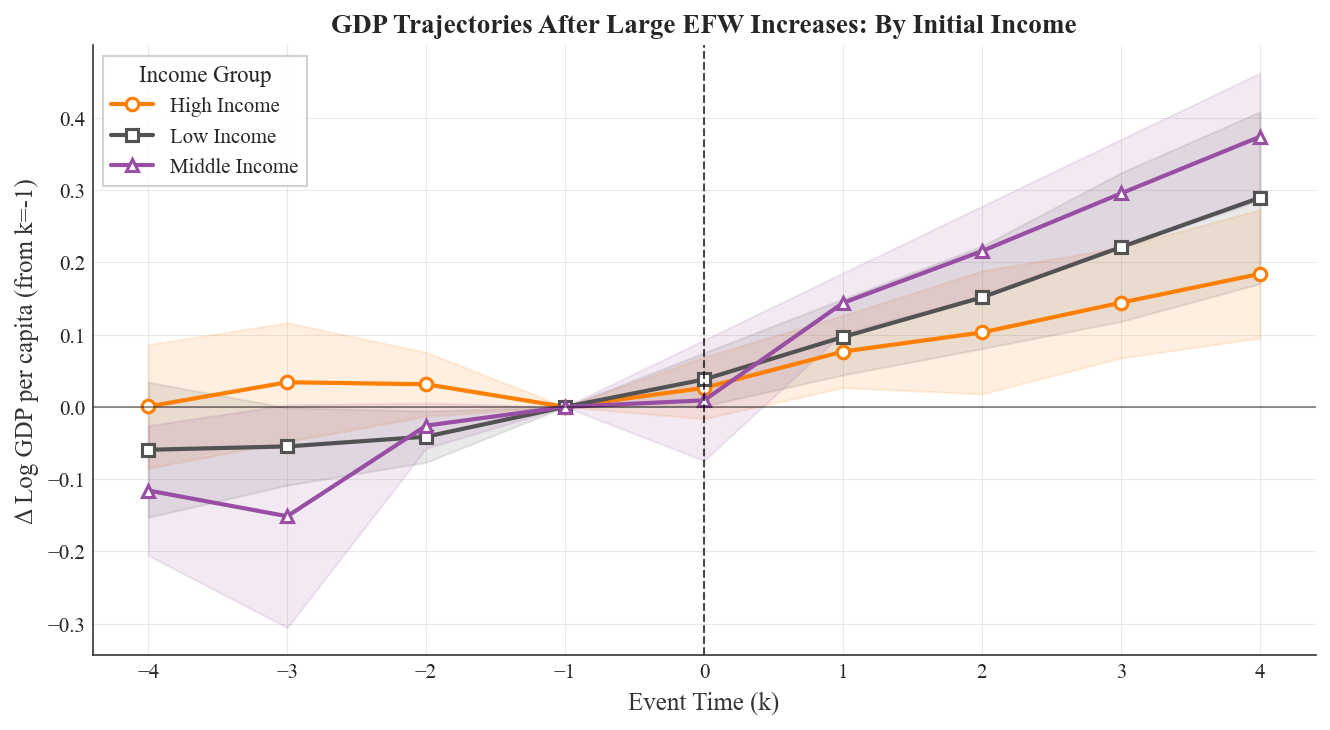

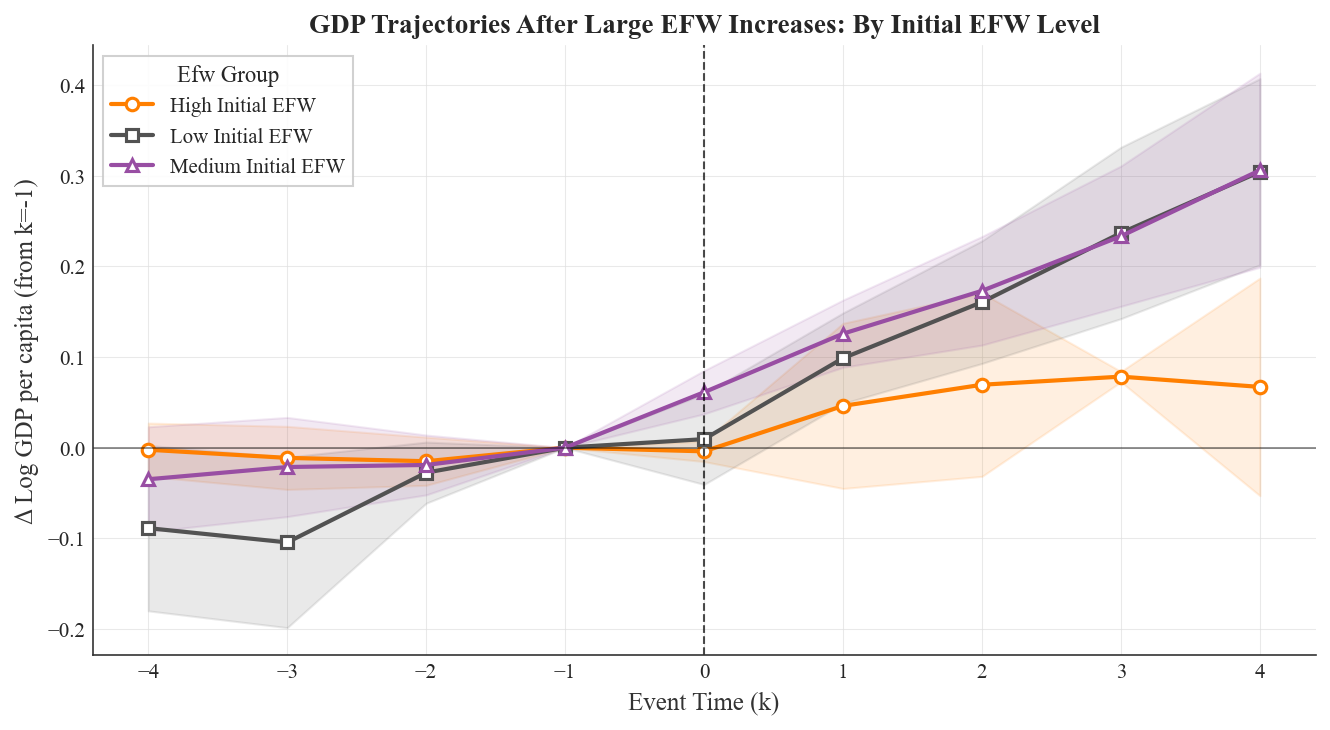

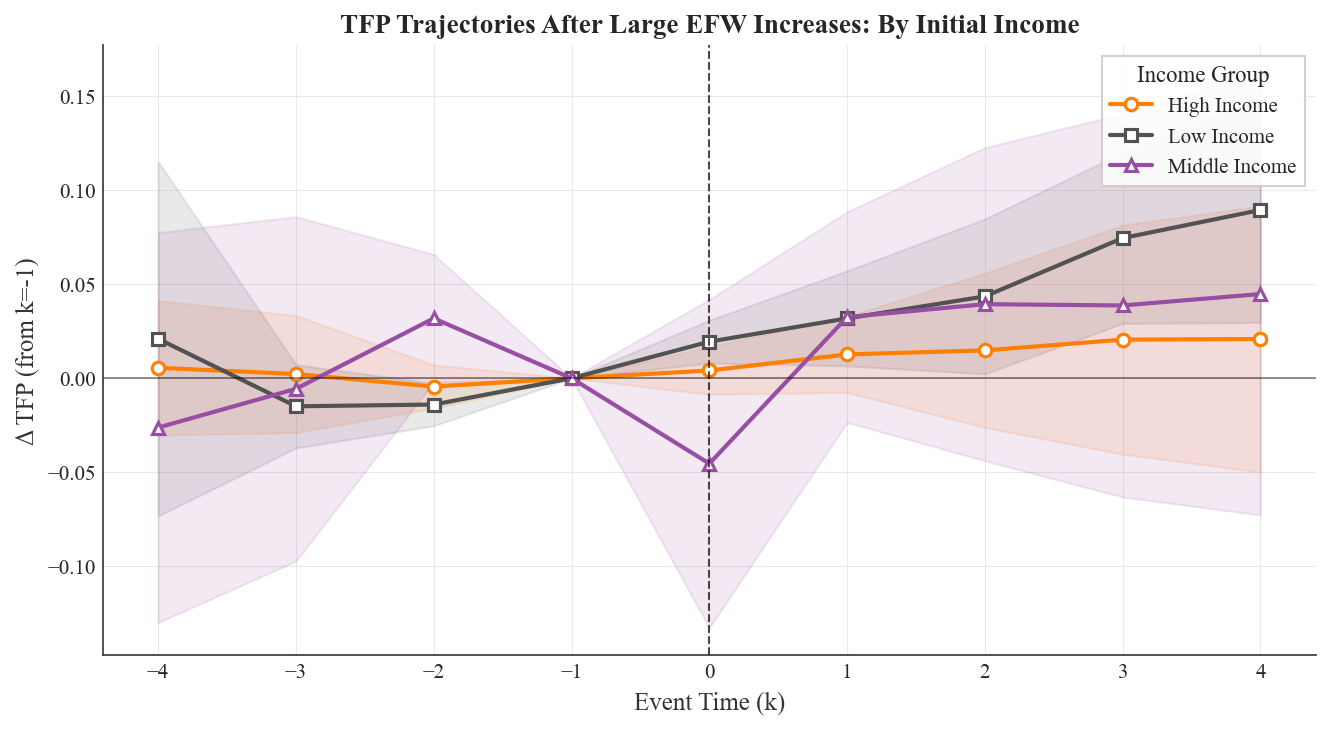

In [11]:
# =============================================================================
# Section 8: State-Dependence Analysis
# =============================================================================

# Add initial GDP per capita to event-time data
initial_gdp = panel.groupby('iso3').agg(
    initial_gdp_pc_log=('pwt_gdp_pc_log', 'first'),
    initial_efw=('efw', 'first'),
).reset_index()

et_combined = et_combined.merge(initial_gdp, on='iso3', how='left')

# Define income groups (terciles based on initial GDP)
gdp_terciles = initial_gdp['initial_gdp_pc_log'].quantile([0.33, 0.67]).values
et_combined['income_group'] = pd.cut(
    et_combined['initial_gdp_pc_log'],
    bins=[-np.inf, gdp_terciles[0], gdp_terciles[1], np.inf],
    labels=['Low Income', 'Middle Income', 'High Income']
)

# Define EFW groups (terciles based on initial EFW)
efw_terciles = initial_gdp['initial_efw'].dropna().quantile([0.33, 0.67]).values
et_combined['efw_group'] = pd.cut(
    et_combined['initial_efw'],
    bins=[-np.inf, efw_terciles[0], efw_terciles[1], np.inf],
    labels=['Low Initial EFW', 'Medium Initial EFW', 'High Initial EFW']
)

print("Income Groups (based on initial log GDP per capita):")
print(f"  Low: < {gdp_terciles[0]:.2f}")
print(f"  Middle: {gdp_terciles[0]:.2f} - {gdp_terciles[1]:.2f}")  
print(f"  High: > {gdp_terciles[1]:.2f}")

print("\nEFW Groups (based on initial EFW):")
print(f"  Low: < {efw_terciles[0]:.2f}")
print(f"  Medium: {efw_terciles[0]:.2f} - {efw_terciles[1]:.2f}")
print(f"  High: > {efw_terciles[1]:.2f}")

# =============================================================================
# State-Dependence Plot Function
# =============================================================================

def plot_state_dependence(
    et_data: pd.DataFrame,
    outcome_var: str,
    state_var: str,
    event_type: str,
    title: str,
    ylabel: str,
    figsize: tuple = (9, 5),
) -> plt.Figure:
    """
    Plot trajectories stratified by initial state.
    """
    var_diff = f'{outcome_var}_diff'
    if var_diff not in et_data.columns:
        return None
    
    subset = et_data[et_data['event_type'] == event_type].copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    states = subset[state_var].dropna().unique()
    colors_list = [COLORS['low_initial'], COLORS['neutral'], COLORS['high_initial']]
    markers = ['o', 's', '^']
    
    for i, state in enumerate(sorted(states)):
        state_data = subset[subset[state_var] == state]
        stats_by_k = state_data.groupby('k')[var_diff].agg(['mean', 'std', 'count']).reset_index()
        stats_by_k['se'] = stats_by_k['std'] / np.sqrt(stats_by_k['count'])
        
        color = colors_list[i % len(colors_list)]
        marker = markers[i % len(markers)]
        
        ax.plot(stats_by_k['k'], stats_by_k['mean'], color=color, marker=marker,
               linewidth=2, label=state, markerfacecolor='white', markeredgewidth=1.5)
        ax.fill_between(stats_by_k['k'],
                       stats_by_k['mean'] - 1.96*stats_by_k['se'],
                       stats_by_k['mean'] + 1.96*stats_by_k['se'],
                       color=color, alpha=0.12)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Event Time (k)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='best', title=state_var.replace('_', ' ').title())
    ax.set_xticks(range(-4, 5))
    
    plt.tight_layout()
    return fig

# =============================================================================
# State-Dependence by Initial Income (for EFW increases)
# =============================================================================

fig = plot_state_dependence(
    et_combined,
    outcome_var='pwt_gdp_pc_log',
    state_var='income_group',
    event_type='large_increase',
    title='GDP Trajectories After Large EFW Increases: By Initial Income',
    ylabel='Δ Log GDP per capita (from k=-1)'
)
if fig:
    save_fig('state_dependence_gdp_by_income_increase')
    plt.show()

# State-dependence by initial EFW
fig = plot_state_dependence(
    et_combined,
    outcome_var='pwt_gdp_pc_log',
    state_var='efw_group',
    event_type='large_increase',
    title='GDP Trajectories After Large EFW Increases: By Initial EFW Level',
    ylabel='Δ Log GDP per capita (from k=-1)'
)
if fig:
    save_fig('state_dependence_gdp_by_efw_increase')
    plt.show()

# TFP state-dependence
fig = plot_state_dependence(
    et_combined,
    outcome_var='pwt_tfp',
    state_var='income_group',
    event_type='large_increase',
    title='TFP Trajectories After Large EFW Increases: By Initial Income',
    ylabel='Δ TFP (from k=-1)'
)
if fig:
    save_fig('state_dependence_tfp_by_income_increase')
    plt.show()

## Section 9: Non-Linearity and Magnitude Analysis

### Economic Question

Do larger EFW changes produce proportionally larger effects, or are there threshold effects?

**Hypotheses:**
1. **Linear**: Effect ∝ |ΔEFW|
2. **Threshold**: Small changes have negligible effects; large changes matter
3. **Diminishing returns**: First units of reform matter most
4. **J-curve**: Initial costs followed by delayed benefits

### Analytical Approach

We compare trajectories across different magnitudes of EFW changes:
- Large (|Δ| ≥ 0.5)
- Moderate (0.3 ≤ |Δ| < 0.5)
- Small (0.1 ≤ |Δ| < 0.3)

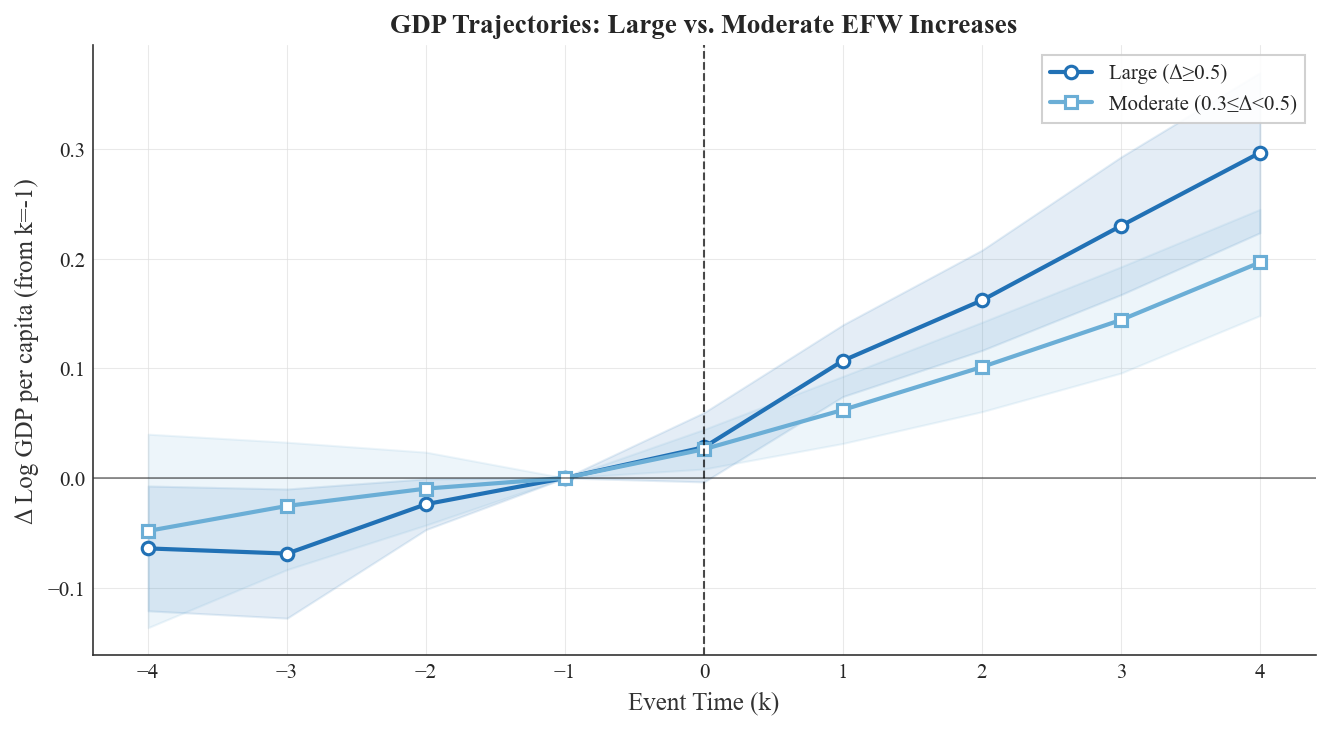

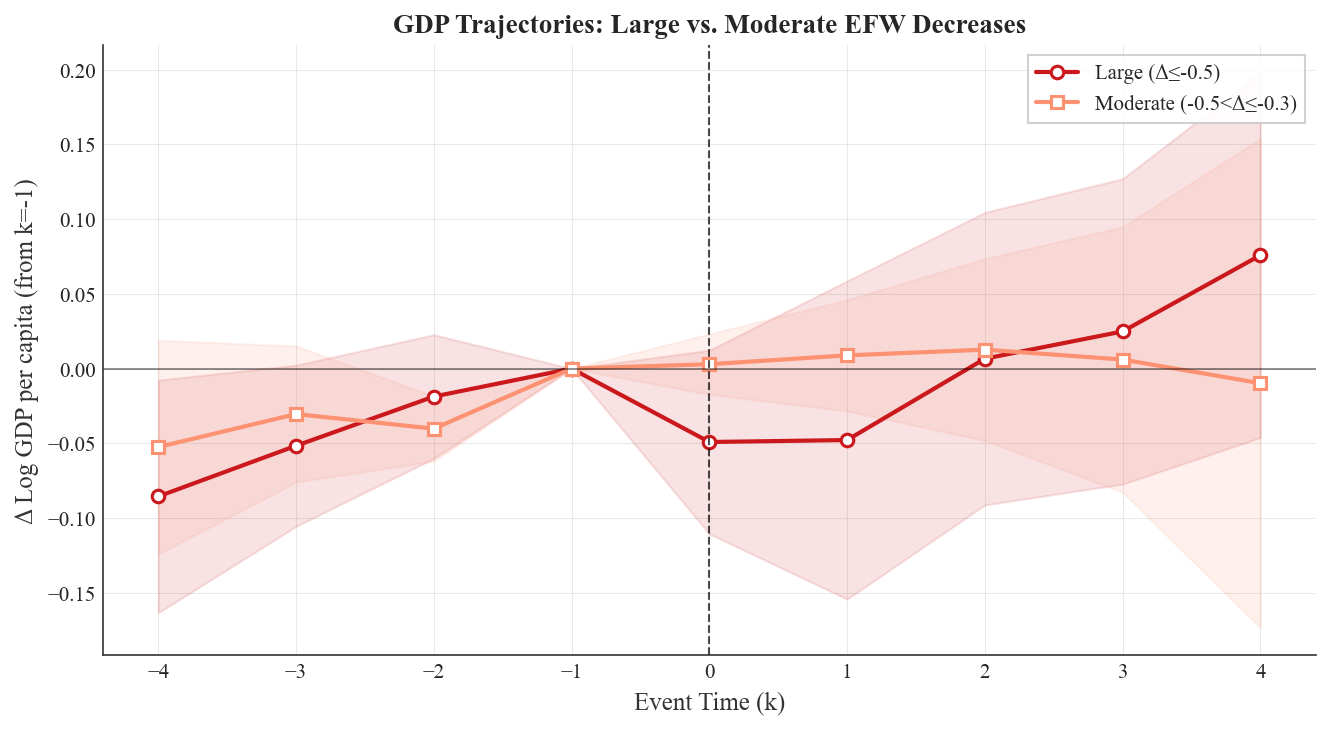

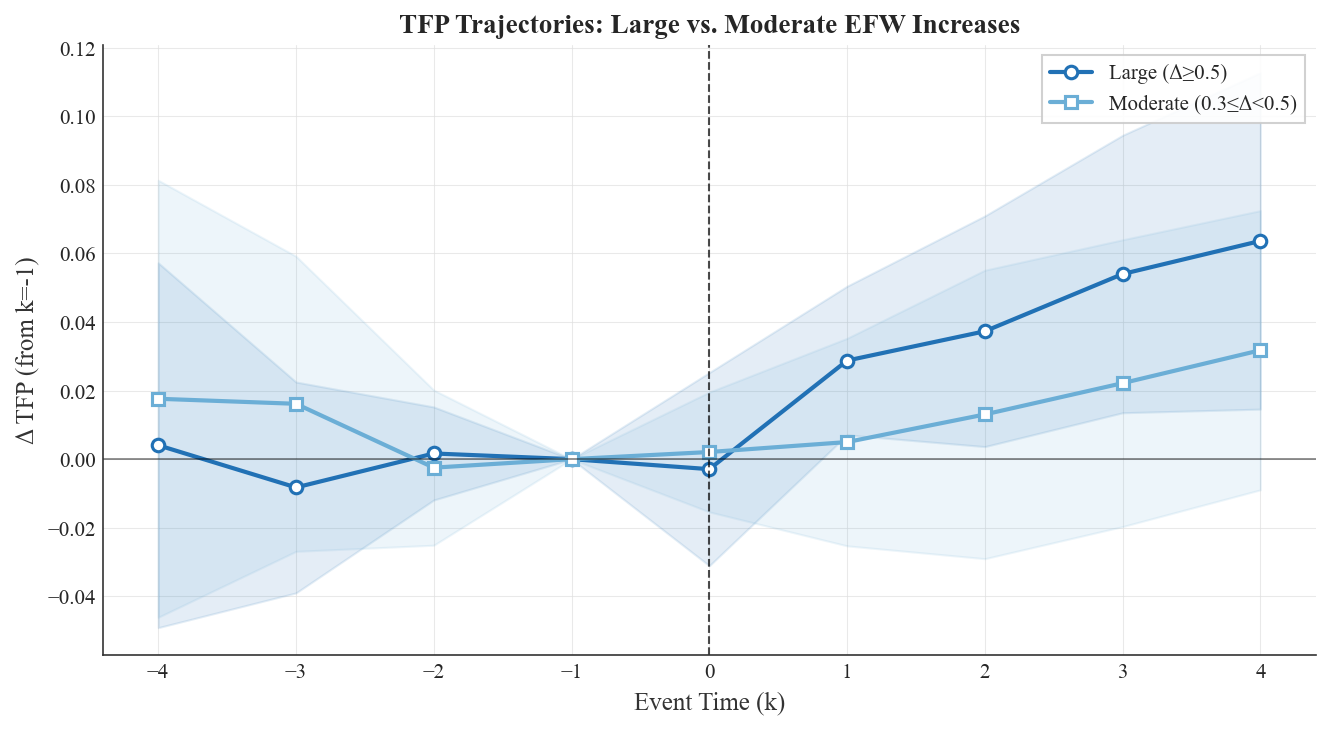

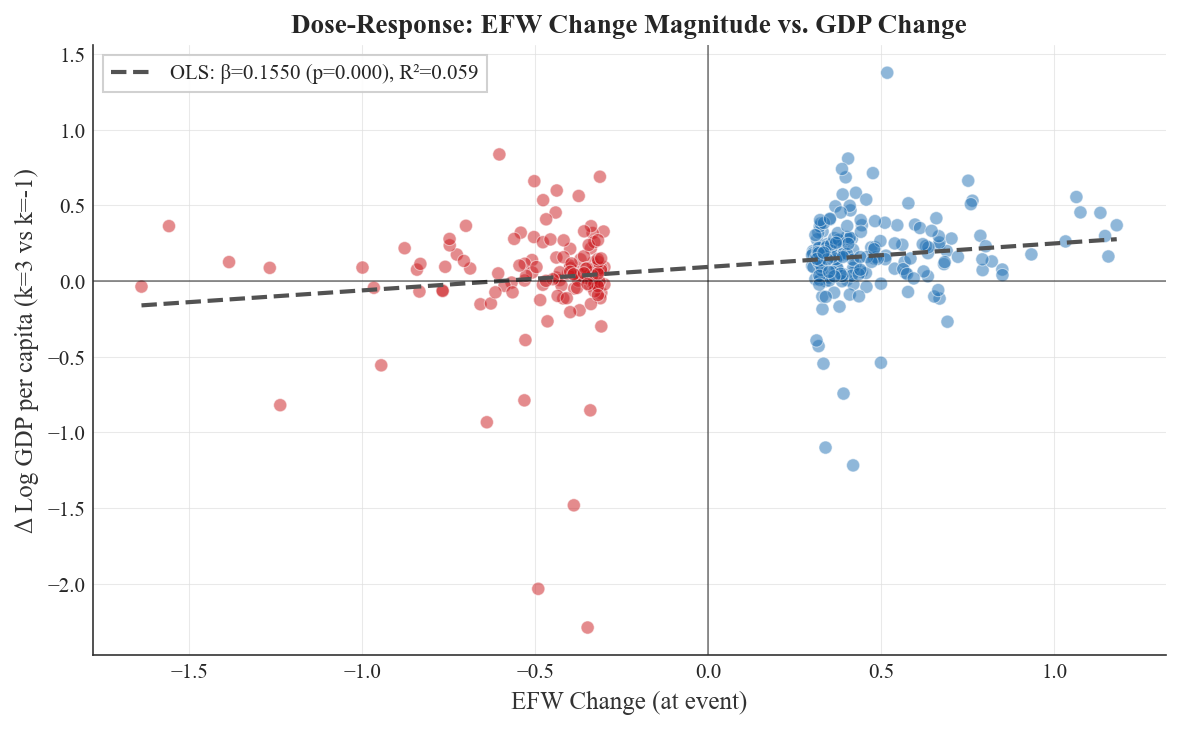

Spearman correlation: ρ = 0.3079, p = 0.0000


In [12]:
# =============================================================================
# Section 9: Non-Linearity and Magnitude Analysis
# =============================================================================

def plot_magnitude_comparison(
    et_data: pd.DataFrame,
    outcome_var: str,
    title: str,
    ylabel: str,
    direction: str = 'increase',  # 'increase' or 'decrease'
    figsize: tuple = (9, 5),
) -> plt.Figure:
    """
    Compare trajectories across different magnitudes of EFW changes.
    """
    var_diff = f'{outcome_var}_diff'
    if var_diff not in et_data.columns:
        return None
    
    fig, ax = plt.subplots(figsize=figsize)
    
    if direction == 'increase':
        configs = [
            ('large_increase', 'Large (Δ≥0.5)', COLORS['increase'], 'o'),
            ('moderate_increase', 'Moderate (0.3≤Δ<0.5)', '#6baed6', 's'),
        ]
    else:
        configs = [
            ('large_decrease', 'Large (Δ≤-0.5)', COLORS['decrease'], 'o'),
            ('moderate_decrease', 'Moderate (-0.5<Δ≤-0.3)', '#fc9272', 's'),
        ]
    
    for event_type, label, color, marker in configs:
        subset = et_data[et_data['event_type'] == event_type]
        stats_by_k = subset.groupby('k')[var_diff].agg(['mean', 'std', 'count']).reset_index()
        stats_by_k['se'] = stats_by_k['std'] / np.sqrt(stats_by_k['count'])
        
        ax.plot(stats_by_k['k'], stats_by_k['mean'], color=color, marker=marker,
               linewidth=2, label=label, markerfacecolor='white', markeredgewidth=1.5)
        ax.fill_between(stats_by_k['k'],
                       stats_by_k['mean'] - 1.96*stats_by_k['se'],
                       stats_by_k['mean'] + 1.96*stats_by_k['se'],
                       color=color, alpha=0.12)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Event Time (k)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='best')
    ax.set_xticks(range(-4, 5))
    
    plt.tight_layout()
    return fig

# GDP: Magnitude comparison for increases
fig = plot_magnitude_comparison(
    et_combined,
    outcome_var='pwt_gdp_pc_log',
    title='GDP Trajectories: Large vs. Moderate EFW Increases',
    ylabel='Δ Log GDP per capita (from k=-1)',
    direction='increase'
)
if fig:
    save_fig('magnitude_gdp_increases')
    plt.show()

# GDP: Magnitude comparison for decreases
fig = plot_magnitude_comparison(
    et_combined,
    outcome_var='pwt_gdp_pc_log',
    title='GDP Trajectories: Large vs. Moderate EFW Decreases',
    ylabel='Δ Log GDP per capita (from k=-1)',
    direction='decrease'
)
if fig:
    save_fig('magnitude_gdp_decreases')
    plt.show()

# TFP: Magnitude comparison
fig = plot_magnitude_comparison(
    et_combined,
    outcome_var='pwt_tfp',
    title='TFP Trajectories: Large vs. Moderate EFW Increases',
    ylabel='Δ TFP (from k=-1)',
    direction='increase'
)
if fig:
    save_fig('magnitude_tfp_increases')
    plt.show()

# =============================================================================
# Dose-Response Analysis: Effect vs. Magnitude
# =============================================================================

def compute_dose_response(
    et_data: pd.DataFrame,
    outcome_var: str,
    k_horizon: int = 3,
) -> pd.DataFrame:
    """
    Compute relationship between EFW change magnitude and outcome change.
    """
    var_diff = f'{outcome_var}_diff'
    if var_diff not in et_data.columns:
        return pd.DataFrame()
    
    # Get k=0 data (at event)
    k0_data = et_data[et_data['k'] == 0][['iso3', 'event_year', 'efw_delta_1y']].copy()
    k0_data = k0_data.rename(columns={'efw_delta_1y': 'efw_change_at_event'})
    
    # Get outcome at horizon
    kh_data = et_data[et_data['k'] == k_horizon][['iso3', 'event_year', var_diff]].copy()
    kh_data = kh_data.rename(columns={var_diff: 'outcome_change'})
    
    # Merge
    dose = k0_data.merge(kh_data, on=['iso3', 'event_year'], how='inner')
    dose = dose.dropna()
    
    return dose

# Compute dose-response for GDP
dose_gdp = compute_dose_response(et_combined, 'pwt_gdp_pc_log', k_horizon=3)

if len(dose_gdp) >= 10:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Scatter plot
    colors = np.where(dose_gdp['efw_change_at_event'] >= 0, COLORS['increase'], COLORS['decrease'])
    ax.scatter(dose_gdp['efw_change_at_event'], dose_gdp['outcome_change'], 
              c=colors, alpha=0.5, s=40, edgecolors='white', linewidth=0.5)
    
    # Linear fit
    mask = ~(dose_gdp['efw_change_at_event'].isna() | dose_gdp['outcome_change'].isna())
    if mask.sum() >= 10:
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            dose_gdp.loc[mask, 'efw_change_at_event'],
            dose_gdp.loc[mask, 'outcome_change']
        )
        x_line = np.linspace(dose_gdp['efw_change_at_event'].min(), dose_gdp['efw_change_at_event'].max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color=COLORS['neutral'], linewidth=2, linestyle='--',
               label=f'OLS: β={slope:.4f} (p={p_value:.3f}), R²={r_value**2:.3f}')
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('EFW Change (at event)')
    ax.set_ylabel('Δ Log GDP per capita (k=3 vs k=-1)')
    ax.set_title('Dose-Response: EFW Change Magnitude vs. GDP Change', fontweight='bold')
    ax.legend(loc='best')
    
    plt.tight_layout()
    save_fig('dose_response_gdp')
    plt.show()
    
    # Report correlation
    corr, p = spearmanr(dose_gdp['efw_change_at_event'], dose_gdp['outcome_change'])
    print(f"Spearman correlation: ρ = {corr:.4f}, p = {p:.4f}")

## Section 10: Logarithmic Specifications and Growth Analysis

### Economic Rationale

Using logarithmic transformations addresses several econometric concerns:

1. **Interpretation**: Log differences approximate percentage changes
   - $\ln(Y_{t}) - \ln(Y_{t-1}) \approx \frac{Y_t - Y_{t-1}}{Y_{t-1}}$ for small changes

2. **Heteroscedasticity**: Variance often scales with level
   - Logs stabilize variance across countries of different sizes

3. **Multiplicative effects**: Economic growth is often multiplicative
   - A 1-unit EFW change might increase GDP by X%, not by $X dollars

### Key Questions

1. Do trajectories look different in percentage terms vs. level changes?
2. Is the EFW-GDP relationship linear in logs (constant elasticity)?
3. How do growth rates (rather than levels) respond to EFW changes?

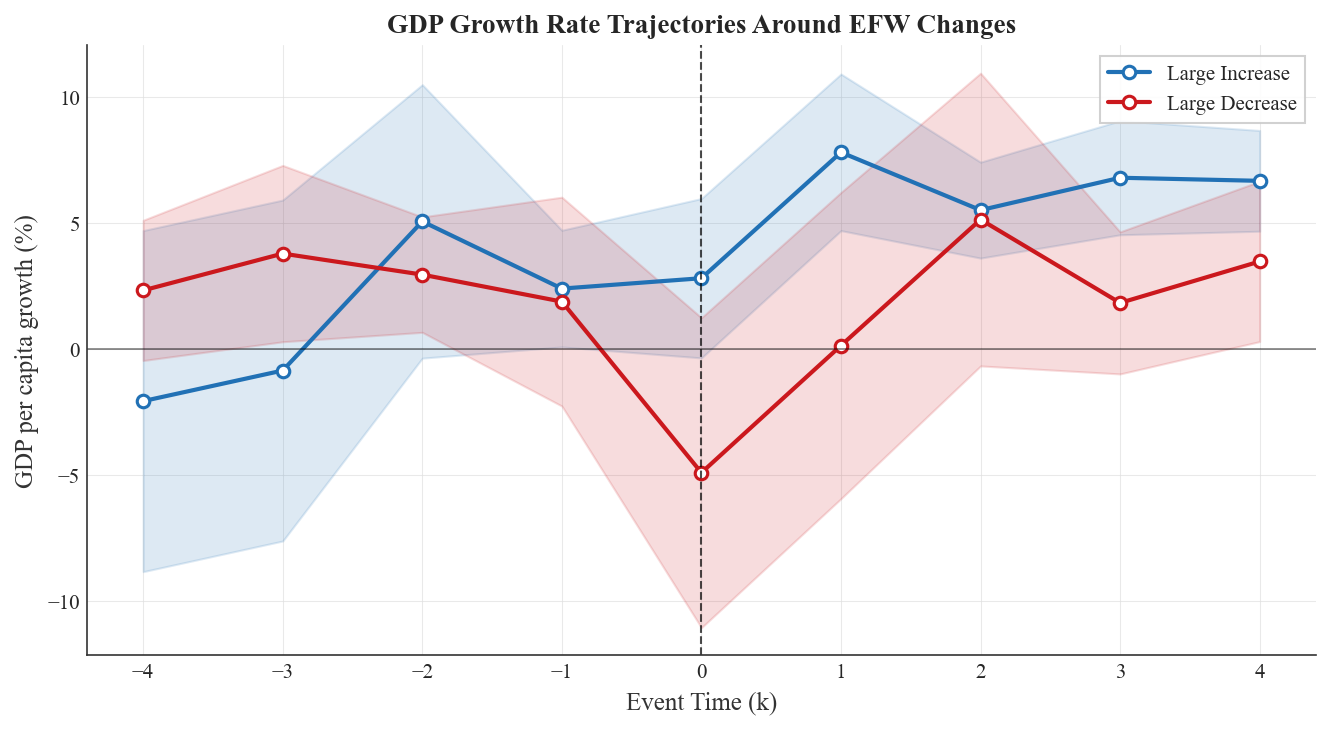


### Log-Log Elasticity: Does EFW have constant elasticity with respect to GDP?

We estimate: $\ln(GDP_{it}) = lpha + eta \ln(EFW_{it}) + \epsilon_{it}$

Where $eta$ represents the elasticity: a 1% increase in EFW is associated with a $eta$% change in GDP.


Pooled OLS Results (Descriptive Only - Not Causal!):
------------------------------------------------------------
Log-Log Specification: ln(GDP) = α + β·ln(EFW) + ε
  Elasticity β = 4.5635 (SE = 0.0851, p < 0.0000)
  Interpretation: 1% ↑ in EFW → 4.56% Δ in GDP per capita
  R² = 0.4312

Log-Level Specification: ln(GDP) = α + β·EFW + ε
  Semi-elasticity β = 0.7863 (SE = 0.0135)
  Interpretation: 1 unit ↑ in EFW → 78.6% Δ in GDP per capita
  R² = 0.4718


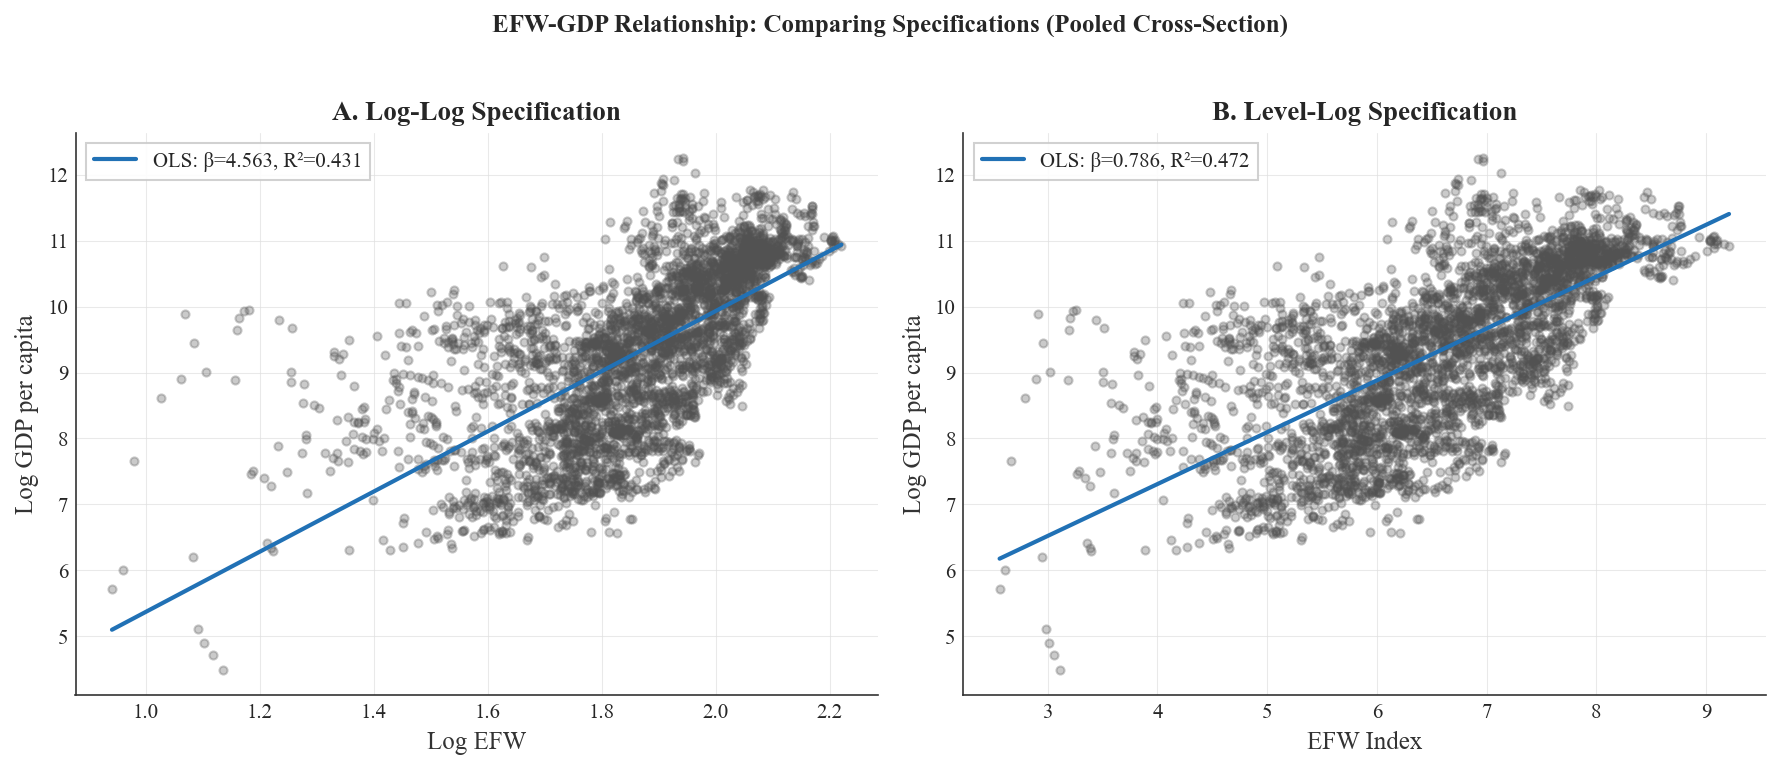


### Within-Country Variation Analysis

To better isolate the EFW effect, we examine within-country variation by demeaning:
$$	ilde{Y}_{it} = Y_{it} - ar{Y}_i$$
$$	ilde{EFW}_{it} = EFW_{it} - \overline{EFW}_i$$

This removes time-invariant country characteristics (similar to country fixed effects).


Within-Country Analysis (Demeaned Variables):
------------------------------------------------------------
Δln(GDP) = β·ΔEFW + ε (within-country variation only)
  β = 0.3628 (SE = 0.0144)
  Interpretation: 1 unit ↑ in EFW (within country) → 36.28% Δ in GDP
  R² = 0.1441
  N = 3,796

Comparison:
  Pooled β: 0.7863
  Within β: 0.3628
  Difference: 0.4235 (53.9%)


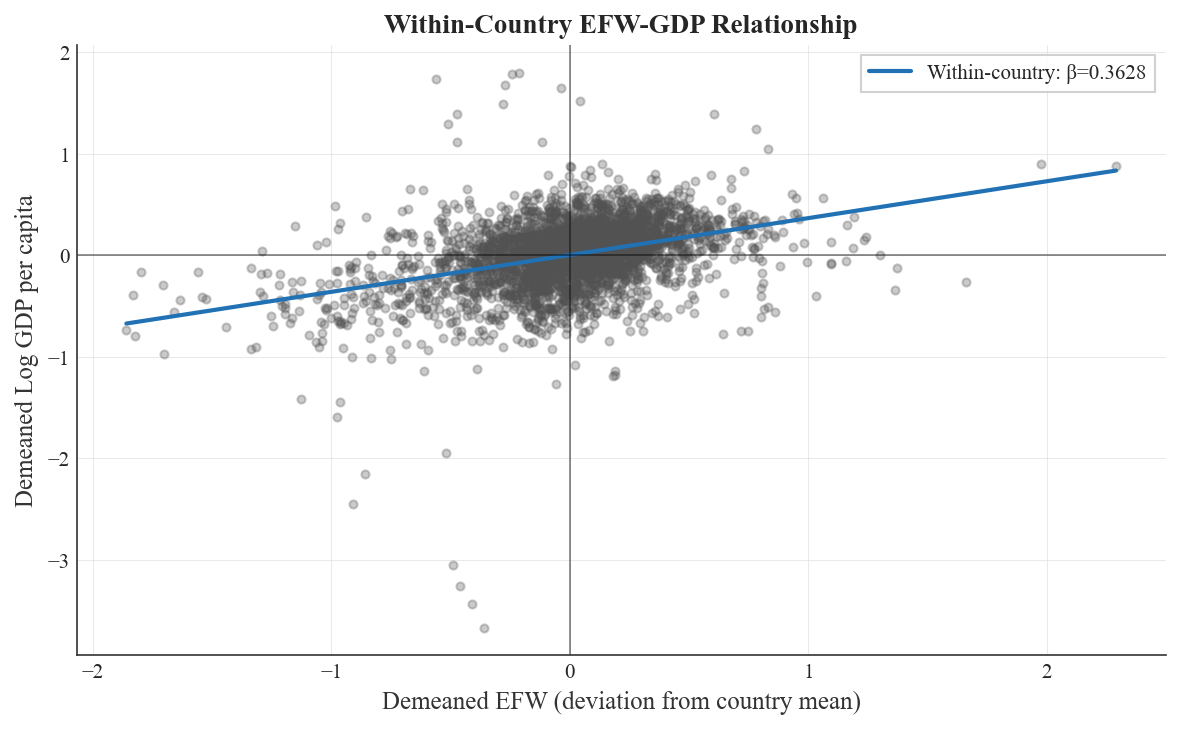

In [13]:
# =============================================================================
# Section 10: Logarithmic Specifications and Growth Analysis
# =============================================================================

# =============================================================================
# 10.1: Growth Rate Trajectories
# =============================================================================

# Add growth rates to event-time data (computed as log differences)
# These are pre-computed in the panel data
panel['pwt_gdp_growth'] = panel.groupby('iso3')['pwt_gdp_pc_log'].diff() * 100  # Convert to percentage points

# Rebuild event-time with growth rates
GROWTH_VARS = ['pwt_gdp_growth', 'wdi_gdp_growth', 'wdi_gdp_pc_growth']
GROWTH_VARS = [v for v in GROWTH_VARS if v in panel.columns]

et_large_increase_growth = build_event_time_dataset(
    panel, 
    event_condition=(panel['efw_delta_1y'] >= THRESHOLD_LARGE),
    outcome_vars=GROWTH_VARS,
    normalize_to=-1,
)
et_large_increase_growth['event_type'] = 'large_increase'

et_large_decrease_growth = build_event_time_dataset(
    panel,
    event_condition=(panel['efw_delta_1y'] <= -THRESHOLD_LARGE),
    outcome_vars=GROWTH_VARS,
    normalize_to=-1,
)
et_large_decrease_growth['event_type'] = 'large_decrease'

et_growth = pd.concat([et_large_increase_growth, et_large_decrease_growth], ignore_index=True)

# Plot: GDP growth rate trajectories (NOT normalized - show absolute levels)
def plot_growth_trajectories(
    et_data: pd.DataFrame,
    growth_var: str,
    title: str,
    ylabel: str,
    figsize: tuple = (9, 5),
) -> plt.Figure:
    """
    Plot growth rate levels (not differences) around events.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    for event_type, color, label in [
        ('large_increase', COLORS['increase'], 'Large Increase'),
        ('large_decrease', COLORS['decrease'], 'Large Decrease'),
    ]:
        subset = et_data[et_data['event_type'] == event_type]
        # Use raw growth rate, not differenced
        stats_by_k = subset.groupby('k')[growth_var].agg(['mean', 'std', 'count']).reset_index()
        stats_by_k = stats_by_k[stats_by_k['count'] >= 5]
        stats_by_k['se'] = stats_by_k['std'] / np.sqrt(stats_by_k['count'])
        
        ax.plot(stats_by_k['k'], stats_by_k['mean'], color=color, marker='o',
               linewidth=2, label=label, markerfacecolor='white', markeredgewidth=1.5)
        ax.fill_between(stats_by_k['k'],
                       stats_by_k['mean'] - 1.96*stats_by_k['se'],
                       stats_by_k['mean'] + 1.96*stats_by_k['se'],
                       color=color, alpha=0.15)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Event Time (k)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='best')
    ax.set_xticks(range(-4, 5))
    
    plt.tight_layout()
    return fig

# Plot growth rate trajectories
if 'pwt_gdp_growth' in et_growth.columns:
    fig = plot_growth_trajectories(
        et_growth,
        growth_var='pwt_gdp_growth',
        title='GDP Growth Rate Trajectories Around EFW Changes',
        ylabel='GDP per capita growth (%)'
    )
    save_fig('trajectory_gdp_growth_rate')
    plt.show()

# =============================================================================
# 10.2: Log-Log Elasticity Analysis
# =============================================================================

display(Markdown("""
### Log-Log Elasticity: Does EFW have constant elasticity with respect to GDP?

We estimate: $\ln(GDP_{it}) = \alpha + \beta \ln(EFW_{it}) + \epsilon_{it}$

Where $\beta$ represents the elasticity: a 1% increase in EFW is associated with a $\beta$% change in GDP.
"""))

# Create log EFW
panel['efw_log'] = np.log(panel['efw'].clip(lower=0.1))

# Simple pooled OLS (descriptive only)
analysis_sample = panel[['iso3', 'year', 'pwt_gdp_pc_log', 'efw_log', 'efw']].dropna()

if len(analysis_sample) >= 100:
    slope_log, intercept_log, r_log, p_log, se_log = stats.linregress(
        analysis_sample['efw_log'], 
        analysis_sample['pwt_gdp_pc_log']
    )
    
    slope_level, intercept_level, r_level, p_level, se_level = stats.linregress(
        analysis_sample['efw'], 
        analysis_sample['pwt_gdp_pc_log']
    )
    
    print("Pooled OLS Results (Descriptive Only - Not Causal!):")
    print("-" * 60)
    print(f"Log-Log Specification: ln(GDP) = α + β·ln(EFW) + ε")
    print(f"  Elasticity β = {slope_log:.4f} (SE = {se_log:.4f}, p < {p_log:.4f})")
    print(f"  Interpretation: 1% ↑ in EFW → {slope_log:.2f}% Δ in GDP per capita")
    print(f"  R² = {r_log**2:.4f}")
    print()
    print(f"Log-Level Specification: ln(GDP) = α + β·EFW + ε")
    print(f"  Semi-elasticity β = {slope_level:.4f} (SE = {se_level:.4f})")
    print(f"  Interpretation: 1 unit ↑ in EFW → {slope_level*100:.1f}% Δ in GDP per capita")
    print(f"  R² = {r_level**2:.4f}")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Log-Log plot
    ax = axes[0]
    ax.scatter(analysis_sample['efw_log'], analysis_sample['pwt_gdp_pc_log'], 
              alpha=0.3, s=15, color=COLORS['neutral'])
    x_line = np.linspace(analysis_sample['efw_log'].min(), analysis_sample['efw_log'].max(), 100)
    y_line = slope_log * x_line + intercept_log
    ax.plot(x_line, y_line, color=COLORS['increase'], linewidth=2,
           label=f'OLS: β={slope_log:.3f}, R²={r_log**2:.3f}')
    ax.set_xlabel('Log EFW')
    ax.set_ylabel('Log GDP per capita')
    ax.set_title('A. Log-Log Specification', fontweight='bold')
    ax.legend(loc='best')
    
    # Level-Log plot
    ax = axes[1]
    ax.scatter(analysis_sample['efw'], analysis_sample['pwt_gdp_pc_log'], 
              alpha=0.3, s=15, color=COLORS['neutral'])
    x_line = np.linspace(analysis_sample['efw'].min(), analysis_sample['efw'].max(), 100)
    y_line = slope_level * x_line + intercept_level
    ax.plot(x_line, y_line, color=COLORS['increase'], linewidth=2,
           label=f'OLS: β={slope_level:.3f}, R²={r_level**2:.3f}')
    ax.set_xlabel('EFW Index')
    ax.set_ylabel('Log GDP per capita')
    ax.set_title('B. Level-Log Specification', fontweight='bold')
    ax.legend(loc='best')
    
    plt.suptitle('EFW-GDP Relationship: Comparing Specifications (Pooled Cross-Section)', 
                fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    save_fig('elasticity_comparison')
    plt.show()

# =============================================================================
# 10.3: Within-Country Variation Analysis
# =============================================================================

display(Markdown("""
### Within-Country Variation Analysis

To better isolate the EFW effect, we examine within-country variation by demeaning:
$$\tilde{Y}_{it} = Y_{it} - \bar{Y}_i$$
$$\tilde{EFW}_{it} = EFW_{it} - \overline{EFW}_i$$

This removes time-invariant country characteristics (similar to country fixed effects).
"""))

# Demean variables
panel['pwt_gdp_pc_log_demeaned'] = panel.groupby('iso3')['pwt_gdp_pc_log'].transform(lambda x: x - x.mean())
panel['efw_demeaned'] = panel.groupby('iso3')['efw'].transform(lambda x: x - x.mean())

within_sample = panel[['iso3', 'year', 'pwt_gdp_pc_log_demeaned', 'efw_demeaned']].dropna()

if len(within_sample) >= 100:
    slope_within, intercept_within, r_within, p_within, se_within = stats.linregress(
        within_sample['efw_demeaned'],
        within_sample['pwt_gdp_pc_log_demeaned']
    )
    
    print("Within-Country Analysis (Demeaned Variables):")
    print("-" * 60)
    print(f"Δln(GDP) = β·ΔEFW + ε (within-country variation only)")
    print(f"  β = {slope_within:.4f} (SE = {se_within:.4f})")
    print(f"  Interpretation: 1 unit ↑ in EFW (within country) → {slope_within*100:.2f}% Δ in GDP")
    print(f"  R² = {r_within**2:.4f}")
    print(f"  N = {len(within_sample):,}")
    
    # Compare with pooled
    print(f"\nComparison:")
    print(f"  Pooled β: {slope_level:.4f}")
    print(f"  Within β: {slope_within:.4f}")
    print(f"  Difference: {slope_level - slope_within:.4f} ({(slope_level - slope_within)/slope_level*100:.1f}%)")

    # Visualization
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(within_sample['efw_demeaned'], within_sample['pwt_gdp_pc_log_demeaned'],
              alpha=0.3, s=15, color=COLORS['neutral'])
    x_line = np.linspace(within_sample['efw_demeaned'].min(), within_sample['efw_demeaned'].max(), 100)
    y_line = slope_within * x_line + intercept_within
    ax.plot(x_line, y_line, color=COLORS['increase'], linewidth=2,
           label=f'Within-country: β={slope_within:.4f}')
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Demeaned EFW (deviation from country mean)')
    ax.set_ylabel('Demeaned Log GDP per capita')
    ax.set_title('Within-Country EFW-GDP Relationship', fontweight='bold')
    ax.legend(loc='best')
    plt.tight_layout()
    save_fig('within_country_relationship')
    plt.show()

## Section 11: Comprehensive Trajectory Dashboard - All PWT Variables

This section provides a systematic view of all key PWT macroeconomic variables, organized by economic category.

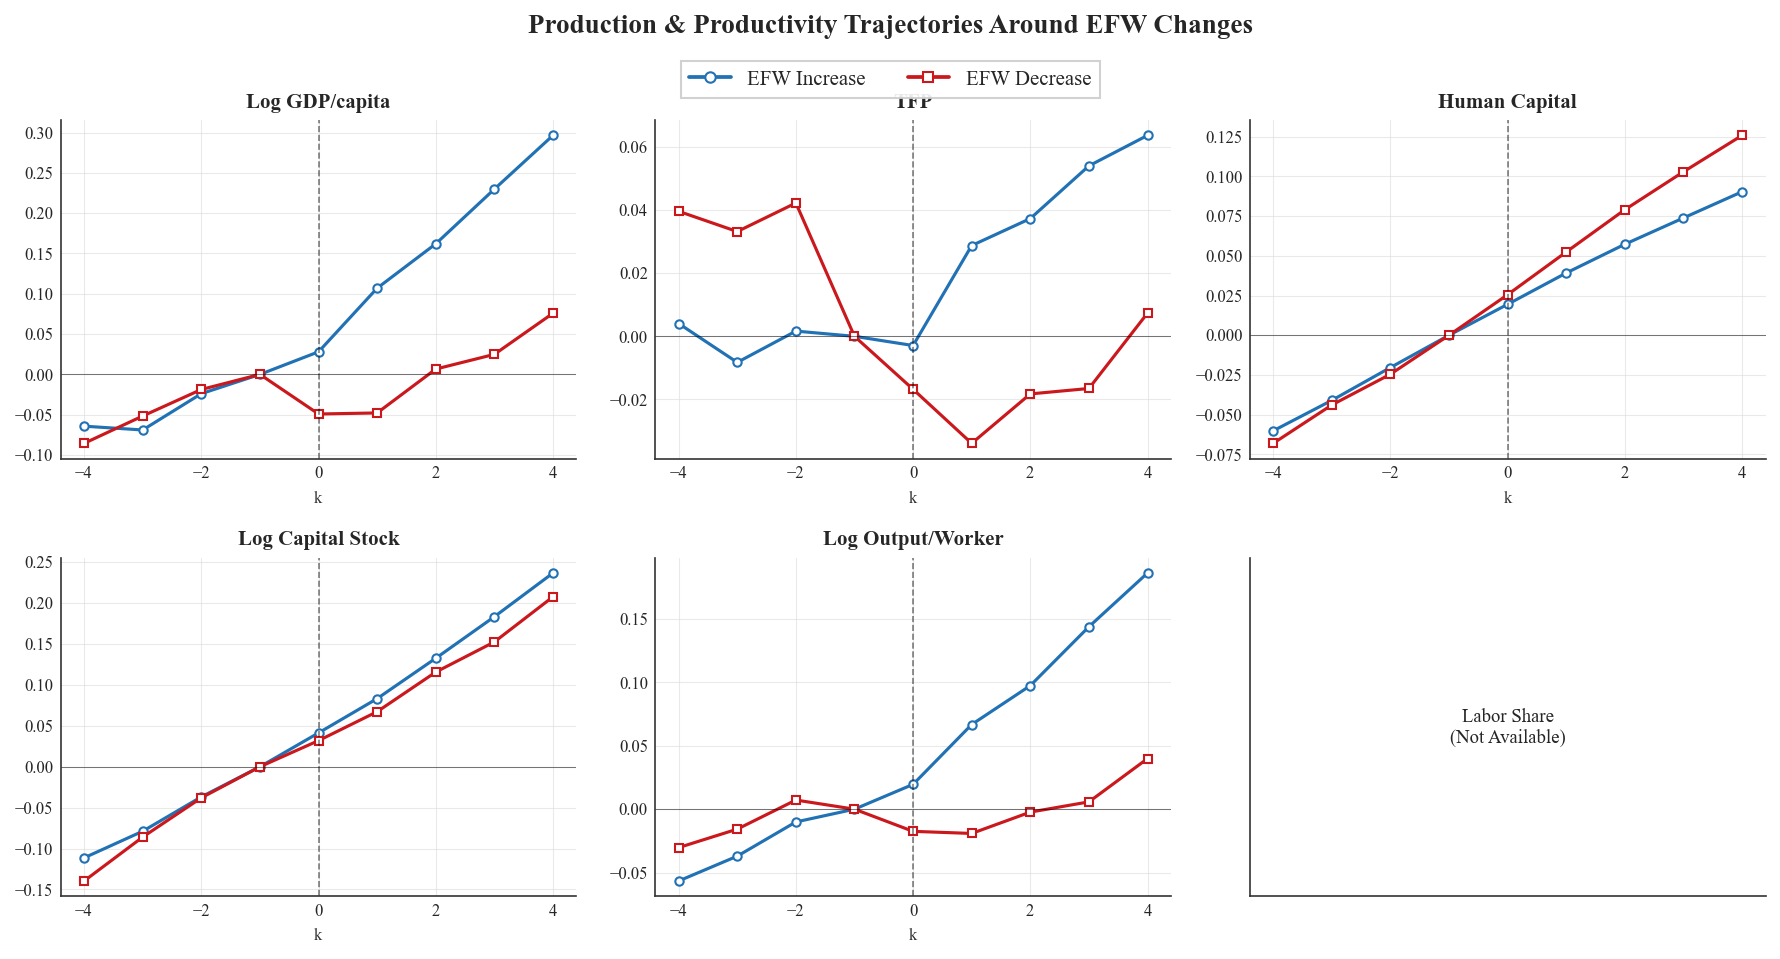

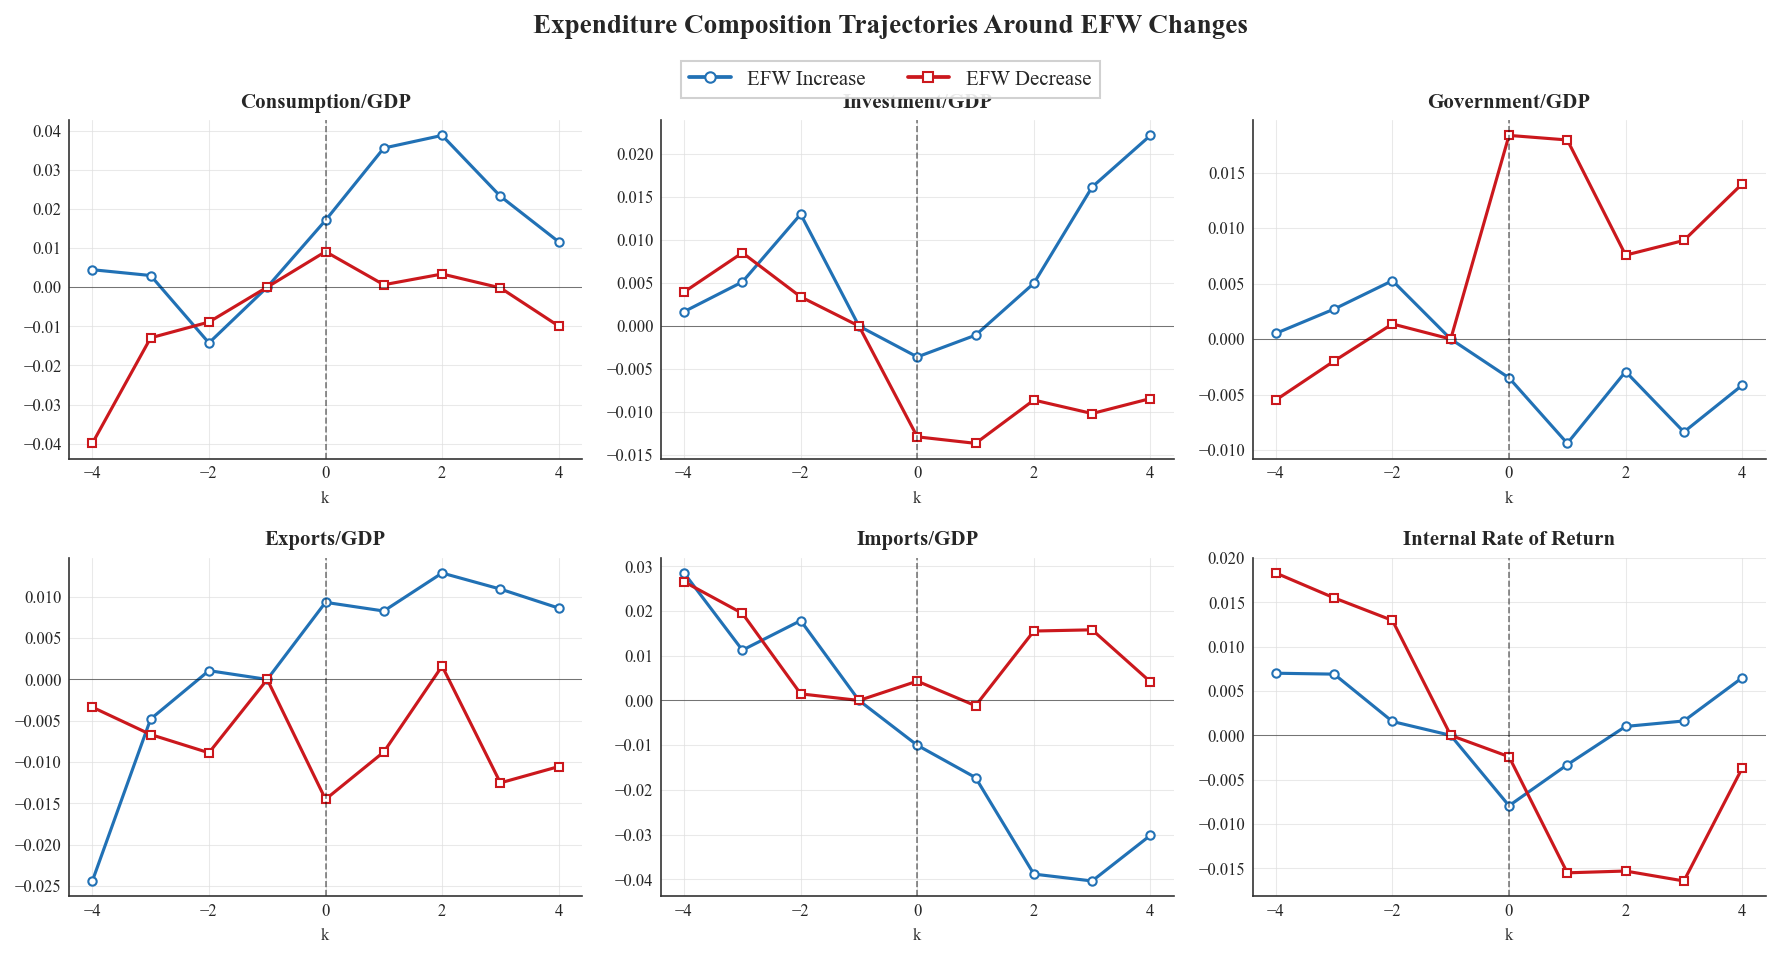

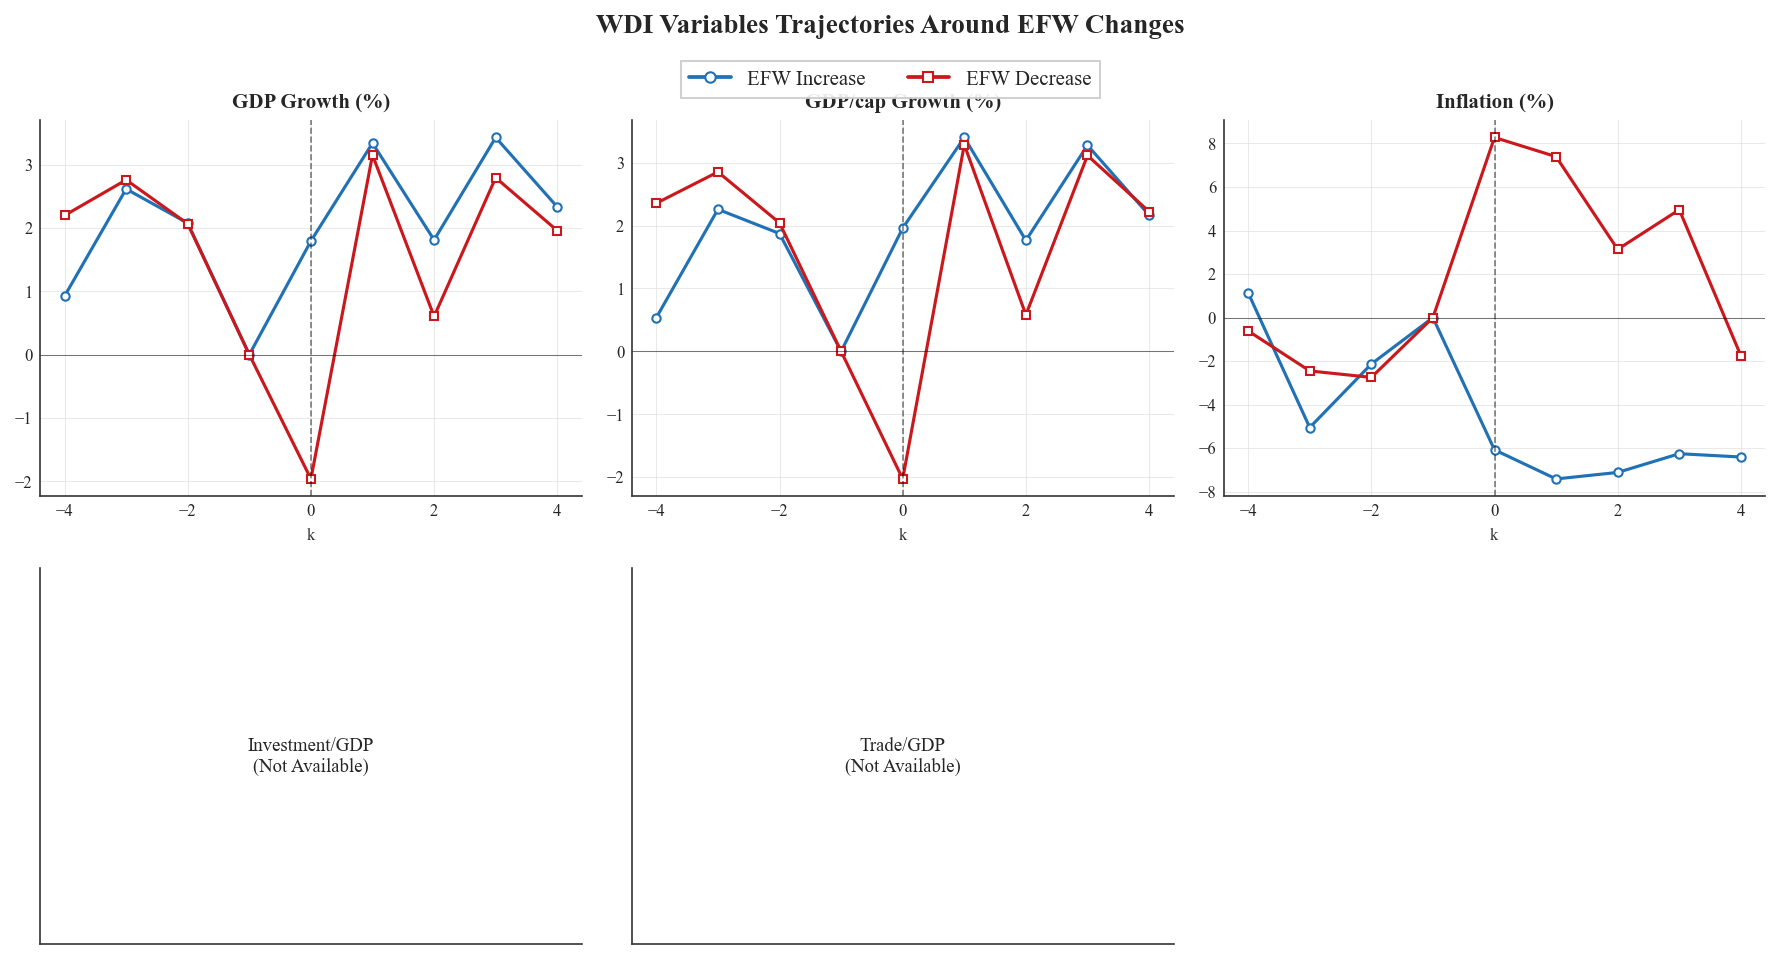

In [14]:
# =============================================================================
# Section 11: Comprehensive Trajectory Dashboard
# =============================================================================

def create_trajectory_dashboard(
    et_data: pd.DataFrame,
    variables: list,
    labels: dict,
    ncols: int = 3,
    figsize_per_plot: tuple = (4, 3),
) -> plt.Figure:
    """
    Create a multi-panel figure showing trajectories for multiple variables.
    """
    nrows = int(np.ceil(len(variables) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_plot[0]*ncols, figsize_per_plot[1]*nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for idx, var in enumerate(variables):
        ax = axes[idx]
        var_diff = f'{var}_diff'
        
        if var_diff not in et_data.columns:
            ax.text(0.5, 0.5, f'{labels.get(var, var)}\n(Not Available)', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        for event_type, color, marker in [
            ('large_increase', COLORS['increase'], 'o'),
            ('large_decrease', COLORS['decrease'], 's'),
        ]:
            subset = et_data[et_data['event_type'] == event_type]
            stats_by_k = subset.groupby('k')[var_diff].agg(['mean', 'count']).reset_index()
            stats_by_k = stats_by_k[stats_by_k['count'] >= 5]
            
            ax.plot(stats_by_k['k'], stats_by_k['mean'], color=color, marker=marker,
                   linewidth=1.5, markersize=4, markerfacecolor='white', markeredgewidth=1)
        
        ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.set_title(labels.get(var, var), fontsize=10, fontweight='bold')
        ax.set_xlabel('k', fontsize=8)
        ax.set_xticks(range(-4, 5, 2))
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots
    for idx in range(len(variables), len(axes)):
        axes[idx].set_visible(False)
    
    # Add legend
    legend_elements = [
        Line2D([0], [0], color=COLORS['increase'], marker='o', markersize=5, 
               markerfacecolor='white', label='EFW Increase'),
        Line2D([0], [0], color=COLORS['decrease'], marker='s', markersize=5,
               markerfacecolor='white', label='EFW Decrease'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=2, 
              bbox_to_anchor=(0.5, 1.02), fontsize=10)
    
    plt.tight_layout()
    return fig

# =============================================================================
# Dashboard 1: Production & Productivity
# =============================================================================

production_vars = ['pwt_gdp_pc_log', 'pwt_tfp', 'pwt_human_capital', 
                  'pwt_capital_stock_log', 'pwt_output_per_worker_log', 'pwt_labor_share']
production_labels = {
    'pwt_gdp_pc_log': 'Log GDP/capita',
    'pwt_tfp': 'TFP',
    'pwt_human_capital': 'Human Capital',
    'pwt_capital_stock_log': 'Log Capital Stock',
    'pwt_output_per_worker_log': 'Log Output/Worker',
    'pwt_labor_share': 'Labor Share',
}
production_vars = [v for v in production_vars if v in panel.columns]

fig = create_trajectory_dashboard(et_combined, production_vars, production_labels)
plt.suptitle('Production & Productivity Trajectories Around EFW Changes', 
            fontsize=13, fontweight='bold', y=1.06)
save_fig('dashboard_production')
plt.show()

# =============================================================================
# Dashboard 2: Expenditure Composition
# =============================================================================

expenditure_vars = ['pwt_consumption_share', 'pwt_investment_share', 'pwt_government_share',
                   'pwt_exports_share', 'pwt_imports_share', 'pwt_irr']
expenditure_labels = {
    'pwt_consumption_share': 'Consumption/GDP',
    'pwt_investment_share': 'Investment/GDP',
    'pwt_government_share': 'Government/GDP',
    'pwt_exports_share': 'Exports/GDP',
    'pwt_imports_share': 'Imports/GDP',
    'pwt_irr': 'Internal Rate of Return',
}
expenditure_vars = [v for v in expenditure_vars if v in panel.columns]

fig = create_trajectory_dashboard(et_combined, expenditure_vars, expenditure_labels)
plt.suptitle('Expenditure Composition Trajectories Around EFW Changes', 
            fontsize=13, fontweight='bold', y=1.06)
save_fig('dashboard_expenditure')
plt.show()

# =============================================================================
# Dashboard 3: WDI Fallback Variables
# =============================================================================

wdi_vars = ['wdi_gdp_growth', 'wdi_gdp_pc_growth', 'wdi_inflation', 
           'wdi_investment_gdp', 'wdi_trade_gdp']
wdi_labels = {
    'wdi_gdp_growth': 'GDP Growth (%)',
    'wdi_gdp_pc_growth': 'GDP/cap Growth (%)',
    'wdi_inflation': 'Inflation (%)',
    'wdi_investment_gdp': 'Investment/GDP',
    'wdi_trade_gdp': 'Trade/GDP',
}
wdi_vars = [v for v in wdi_vars if v in panel.columns]

if wdi_vars:
    fig = create_trajectory_dashboard(et_combined, wdi_vars, wdi_labels, ncols=3)
    plt.suptitle('WDI Variables Trajectories Around EFW Changes', 
                fontsize=13, fontweight='bold', y=1.06)
    save_fig('dashboard_wdi')
    plt.show()

## Section 12: EFW Sub-Components Analysis

### Decomposing Economic Freedom

The EFW index consists of five areas that capture different dimensions of economic freedom:

1. **Area 1 - Size of Government**: Government consumption, transfers, government enterprises, marginal tax rates
2. **Area 2 - Legal System**: Property rights, judicial independence, impartial courts, military interference
3. **Area 3 - Sound Money**: Money growth, inflation, freedom to own foreign currency
4. **Area 4 - Freedom to Trade**: Tariffs, regulatory trade barriers, capital controls
5. **Area 5 - Regulation**: Credit market, labor market, business regulations

Different areas may have different effects on macroeconomic outcomes due to distinct transmission mechanisms.

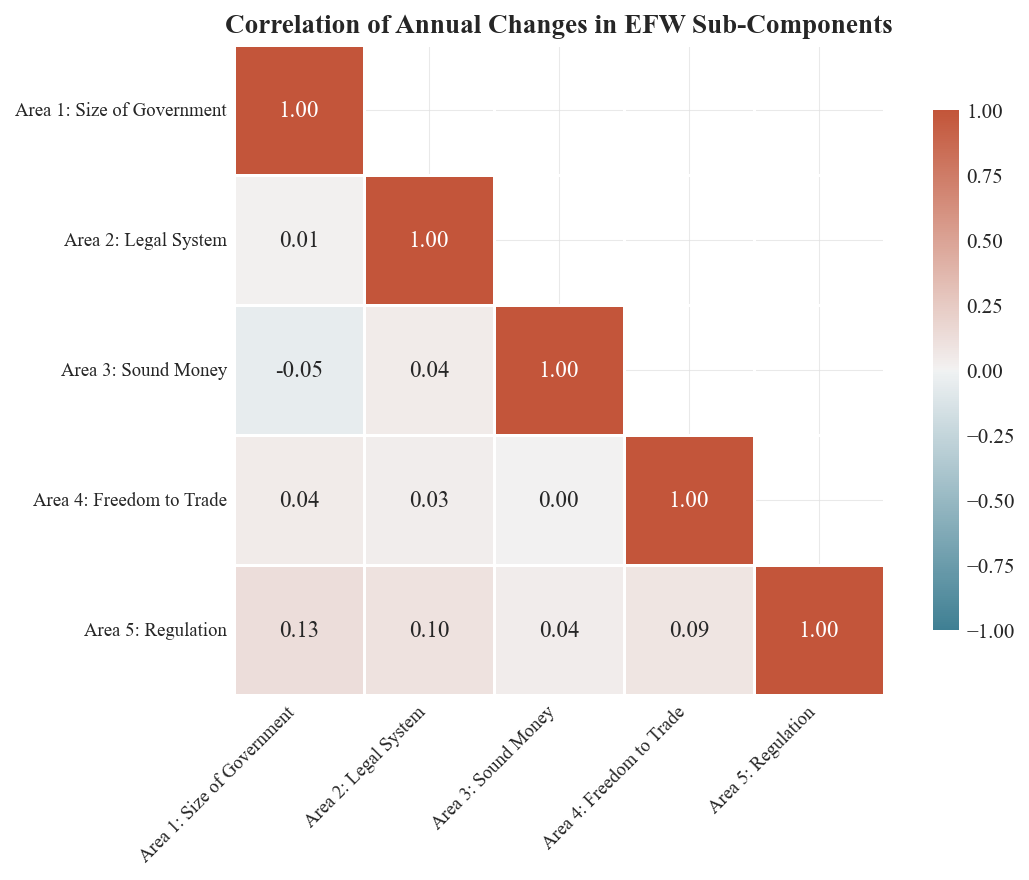


### Which EFW Areas Drive Large Aggregate Changes?

When the aggregate EFW index changes by ≥0.5 (or ≤-0.5), which sub-components are responsible?


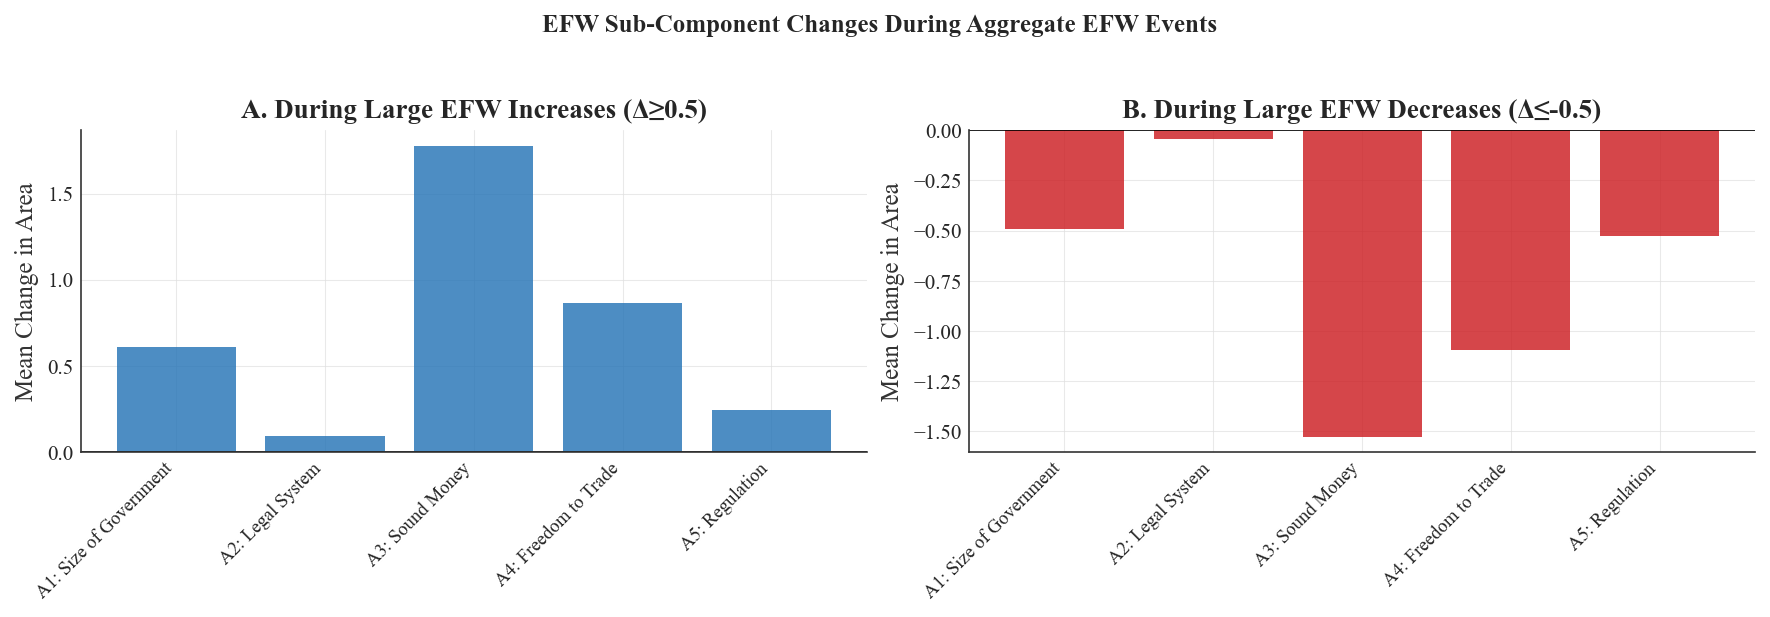

### Correlation of EFW Area Changes with GDP Growth

,Area,Correlation,P-value,N,Significant (5%)
3,Area 4: Freedom to Trade,0.0965,0.0000,3346,✓
4,Area 5: Regulation,0.0705,0.0000,3703,✓
2,Area 3: Sound Money,0.0527,0.0014,3680,✓
1,Area 2: Legal System,0.0319,0.0541,3646,
0,Area 1: Size of Government,0.0069,0.6758,3671,


In [15]:
# =============================================================================
# Section 12: EFW Sub-Components Analysis
# =============================================================================

EFW_AREAS = {
    'efw_area1_government': 'Area 1: Size of Government',
    'efw_area2_legal': 'Area 2: Legal System',
    'efw_area3_money': 'Area 3: Sound Money',
    'efw_area4_trade': 'Area 4: Freedom to Trade',
    'efw_area5_regulation': 'Area 5: Regulation',
}

# Compute changes in each area
for area in EFW_AREAS.keys():
    if area in panel.columns:
        panel[f'{area}_delta'] = panel.groupby('iso3')[area].diff()

# =============================================================================
# Correlation Matrix of EFW Area Changes
# =============================================================================

area_changes = [f'{a}_delta' for a in EFW_AREAS.keys() if f'{a}_delta' in panel.columns]
if area_changes:
    corr_matrix = panel[area_changes].corr()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create heatmap
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    
    sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
               annot=True, fmt='.2f', square=True, linewidths=0.5,
               xticklabels=[EFW_AREAS[a.replace('_delta', '')] for a in area_changes],
               yticklabels=[EFW_AREAS[a.replace('_delta', '')] for a in area_changes],
               ax=ax, cbar_kws={'shrink': 0.8})
    
    ax.set_title('Correlation of Annual Changes in EFW Sub-Components', fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    save_fig('efw_area_change_correlations')
    plt.show()

# =============================================================================
# Which Area Changes Drive Aggregate EFW Changes?
# =============================================================================

display(Markdown("""
### Which EFW Areas Drive Large Aggregate Changes?

When the aggregate EFW index changes by ≥0.5 (or ≤-0.5), which sub-components are responsible?
"""))

# For large increases
large_inc_mask = panel['efw_delta_1y'] >= THRESHOLD_LARGE
if large_inc_mask.sum() > 0:
    area_contrib_inc = panel.loc[large_inc_mask, area_changes].mean()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Large increases
    ax = axes[0]
    colors_inc = [COLORS['increase'] if v > 0 else COLORS['decrease'] for v in area_contrib_inc.values]
    bars = ax.bar(range(len(area_contrib_inc)), area_contrib_inc.values, color=colors_inc, alpha=0.8)
    ax.set_xticks(range(len(area_contrib_inc)))
    ax.set_xticklabels([EFW_AREAS[a.replace('_delta', '')].replace('Area ', 'A') for a in area_changes], 
                      rotation=45, ha='right', fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Mean Change in Area')
    ax.set_title('A. During Large EFW Increases (Δ≥0.5)', fontweight='bold')
    
    # Large decreases
    large_dec_mask = panel['efw_delta_1y'] <= -THRESHOLD_LARGE
    if large_dec_mask.sum() > 0:
        area_contrib_dec = panel.loc[large_dec_mask, area_changes].mean()
        ax = axes[1]
        colors_dec = [COLORS['increase'] if v > 0 else COLORS['decrease'] for v in area_contrib_dec.values]
        bars = ax.bar(range(len(area_contrib_dec)), area_contrib_dec.values, color=colors_dec, alpha=0.8)
        ax.set_xticks(range(len(area_contrib_dec)))
        ax.set_xticklabels([EFW_AREAS[a.replace('_delta', '')].replace('Area ', 'A') for a in area_changes], 
                          rotation=45, ha='right', fontsize=9)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_ylabel('Mean Change in Area')
        ax.set_title('B. During Large EFW Decreases (Δ≤-0.5)', fontweight='bold')
    
    plt.suptitle('EFW Sub-Component Changes During Aggregate EFW Events', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    save_fig('efw_area_contributions')
    plt.show()

# =============================================================================
# Area-Specific Effects on GDP
# =============================================================================

# Simple correlation analysis: which area changes correlate most with GDP changes?
if 'pwt_gdp_pc_log' in panel.columns:
    # Create GDP growth variable
    panel['pwt_gdp_pc_log_growth'] = panel.groupby('iso3')['pwt_gdp_pc_log'].diff()
    
    correlations = []
    for area in area_changes:
        if area in panel.columns:
            mask = panel[area].notna() & panel['pwt_gdp_pc_log_growth'].notna()
            if mask.sum() >= 30:
                corr, pval = pearsonr(panel.loc[mask, area], panel.loc[mask, 'pwt_gdp_pc_log_growth'])
                correlations.append({
                    'Area': EFW_AREAS[area.replace('_delta', '')],
                    'Correlation': corr,
                    'P-value': pval,
                    'N': mask.sum(),
                    'Significant (5%)': '✓' if pval < 0.05 else '',
                })
    
    if correlations:
        corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)
        save_table(corr_df, 'area_gdp_correlations')
        display(Markdown("### Correlation of EFW Area Changes with GDP Growth"))
        display(corr_df.round(4))

## Section 13: Pre-Trends and Reverse Causality Diagnostics

### Identification Concerns

A critical question for causal interpretation is whether:
1. **Pre-trends exist**: Are macro outcomes already trending before EFW changes?
2. **Reverse causality**: Do economic conditions predict EFW changes?

If countries that will experience EFW increases are already growing faster at $k<0$, the post-event trajectory may simply continue a pre-existing trend rather than reflect a causal effect.

### Diagnostic Tests

1. **Parallel pre-trends**: Do increase and decrease groups have similar trajectories before $k=0$?
2. **Granger-style test**: Does lagged GDP predict EFW changes?
3. **Event predictor analysis**: What predicts large EFW changes?

### Pre-Trend Test Results

*Testing whether increase vs. decrease groups have different outcomes before the event (k<0)*

**P-values for difference between groups at each pre-event period:**

k,-4,-3,-2,-1
variable,,,,
GDP Growth (WDI),0.6930,0.9610,0.9960,NaN
Investment Share of GDP (PWT),0.8930,0.8310,0.3930,NaN
Log GDP per capita (PWT),0.6660,0.6720,0.8320,NaN
Total Factor Productivity (PWT),0.6020,0.3760,0.2130,NaN


✓ No significant pre-trend differences detected at conventional levels.


### What Predicts Large EFW Changes?

Examining predictors of large EFW changes helps understand selection into "treatment."


### Comparison of Lagged Values: Large EFW Change Events vs. Non-Events

,Predictor (lagged),Mean (Events),Mean (Non-Events),Difference,t-statistic,p-value,Cohen's d
0,pwt_gdp_pc_log,8.6206,9.3336,-0.7130,-6.1195,0.0000,-0.5757
1,pwt_gdp_growth,0.0215,0.0296,-0.0081,-0.6907,0.4914,-0.0870
2,wdi_inflation,13.7132,6.6345,7.0787,4.7413,0.0000,0.3529
3,efw,5.4350,6.5809,-1.1459,-11.5831,0.0000,-1.0662


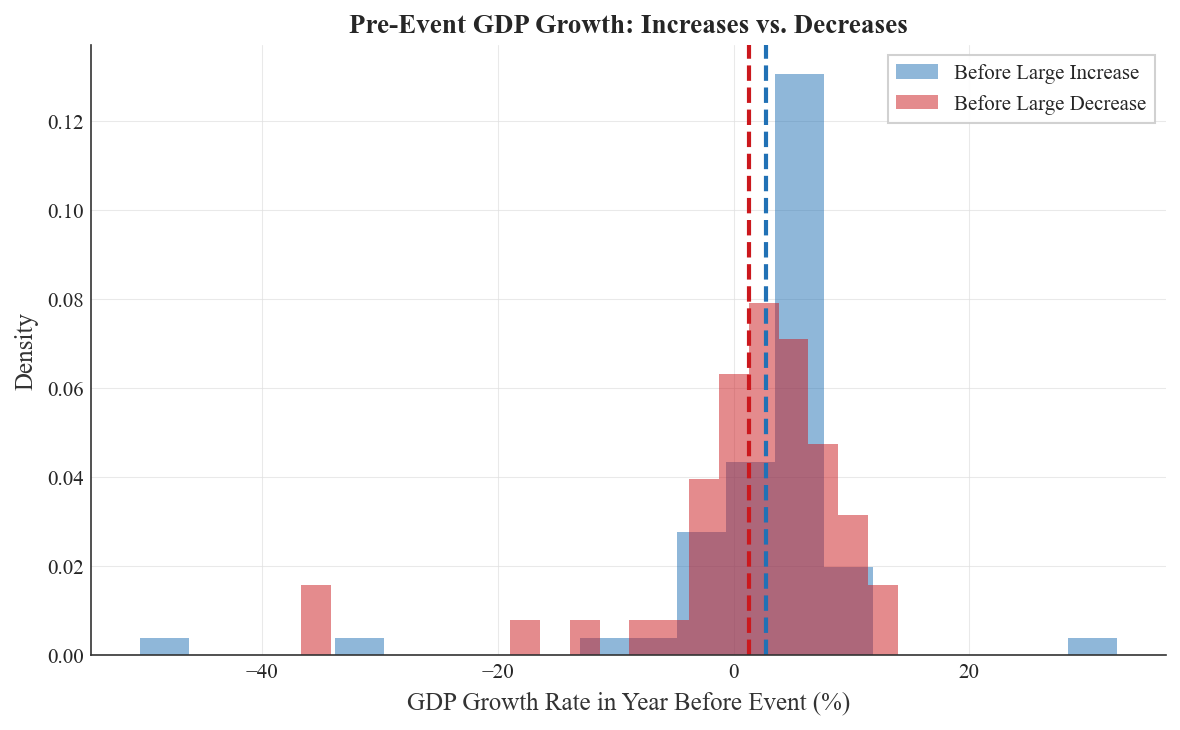

In [16]:
# =============================================================================
# Section 13: Pre-Trends and Reverse Causality Diagnostics
# =============================================================================

# =============================================================================
# 13.1: Pre-Trend Tests
# =============================================================================

def test_pre_trends(
    et_data: pd.DataFrame,
    outcome_var: str,
    k_pre_range: tuple = (-4, -1),
) -> dict:
    """
    Test whether trajectories differ between increase and decrease groups before the event.
    
    Under the null of parallel pre-trends, the groups should have similar trajectories for k < 0.
    """
    var_diff = f'{outcome_var}_diff'
    if var_diff not in et_data.columns:
        return {}
    
    k_min, k_max = k_pre_range
    results = {}
    
    for k in range(k_min, k_max + 1):
        inc_data = et_data[(et_data['event_type'] == 'large_increase') & (et_data['k'] == k)][var_diff].dropna()
        dec_data = et_data[(et_data['event_type'] == 'large_decrease') & (et_data['k'] == k)][var_diff].dropna()
        
        if len(inc_data) >= 5 and len(dec_data) >= 5:
            t_stat, t_pval = ttest_ind(inc_data, dec_data, equal_var=False)
            results[k] = {
                'k': k,
                'mean_increase': inc_data.mean(),
                'mean_decrease': dec_data.mean(),
                'difference': inc_data.mean() - dec_data.mean(),
                't_statistic': t_stat,
                'p_value': t_pval,
                'significant_5pct': t_pval < 0.05,
            }
    
    return results

# Test pre-trends for key variables
pre_trend_vars = ['pwt_gdp_pc_log', 'pwt_tfp', 'pwt_investment_share', 'wdi_gdp_growth']
pre_trend_vars = [v for v in pre_trend_vars if v in OUTCOME_VARS_ANALYSIS]

pre_trend_results = []
for var in pre_trend_vars:
    results = test_pre_trends(et_combined, var, k_pre_range=(-4, -1))
    for k, r in results.items():
        r['variable'] = OUTCOME_VARS.get(var, var)
        pre_trend_results.append(r)

if pre_trend_results:
    pre_trend_df = pd.DataFrame(pre_trend_results)
    save_table(pre_trend_df, 'pre_trend_tests')
    
    display(Markdown("### Pre-Trend Test Results"))
    display(Markdown("*Testing whether increase vs. decrease groups have different outcomes before the event (k<0)*"))
    
    # Pivot for display
    pivot_df = pre_trend_df.pivot(index='variable', columns='k', values='p_value')
    display(Markdown("**P-values for difference between groups at each pre-event period:**"))
    display(pivot_df.round(3))
    
    # Interpretation
    any_significant = pre_trend_df['significant_5pct'].any()
    if any_significant:
        display(Markdown("⚠️ **Warning**: Some pre-event periods show significant differences between groups. This suggests potential selection or pre-existing trends."))
    else:
        display(Markdown("✓ No significant pre-trend differences detected at conventional levels."))

# =============================================================================
# 13.2: What Predicts Large EFW Changes?
# =============================================================================

display(Markdown("""
### What Predicts Large EFW Changes?

Examining predictors of large EFW changes helps understand selection into "treatment."
"""))

# Create event indicator
panel['large_efw_change'] = np.where(
    panel['efw_delta_1y'].abs() >= THRESHOLD_LARGE, 1, 
    np.where(panel['efw_delta_1y'].notna(), 0, np.nan)
)

# Compute lagged predictors
panel['pwt_gdp_pc_log_lag1'] = panel.groupby('iso3')['pwt_gdp_pc_log'].shift(1)
panel['pwt_gdp_growth_lag1'] = panel.groupby('iso3')['pwt_gdp_pc_log'].diff().shift(1)
panel['wdi_inflation_lag1'] = panel.groupby('iso3')['wdi_inflation'].shift(1)
panel['efw_lag1_level'] = panel.groupby('iso3')['efw'].shift(1)

# Compare predictors between events and non-events
predictor_vars = ['pwt_gdp_pc_log_lag1', 'pwt_gdp_growth_lag1', 'wdi_inflation_lag1', 'efw_lag1_level']
predictor_vars = [v for v in predictor_vars if v in panel.columns]

predictor_comparison = []
for var in predictor_vars:
    events = panel[panel['large_efw_change'] == 1][var].dropna()
    non_events = panel[panel['large_efw_change'] == 0][var].dropna()
    
    if len(events) >= 10 and len(non_events) >= 10:
        t_stat, p_val = ttest_ind(events, non_events, equal_var=False)
        d = cohen_d(events.values, non_events.values)
        
        predictor_comparison.append({
            'Predictor (lagged)': var.replace('_lag1', '').replace('_level', ''),
            'Mean (Events)': events.mean(),
            'Mean (Non-Events)': non_events.mean(),
            'Difference': events.mean() - non_events.mean(),
            't-statistic': t_stat,
            'p-value': p_val,
            "Cohen's d": d,
        })

if predictor_comparison:
    pred_df = pd.DataFrame(predictor_comparison)
    save_table(pred_df, 'event_predictors')
    display(Markdown("### Comparison of Lagged Values: Large EFW Change Events vs. Non-Events"))
    display(pred_df.round(4))

# =============================================================================
# 13.3: Granger-Style Visualization
# =============================================================================

# Do GDP dynamics predict EFW changes?
fig, ax = plt.subplots(figsize=(8, 5))

# For each event type, plot GDP growth in the year BEFORE the event
for event_type, color, label in [
    ('large_increase', COLORS['increase'], 'Before Large Increase'),
    ('large_decrease', COLORS['decrease'], 'Before Large Decrease'),
]:
    # Get GDP growth in year before event
    events_k_minus1 = et_combined[(et_combined['event_type'] == event_type) & (et_combined['k'] == -1)]
    if 'wdi_gdp_growth' in events_k_minus1.columns:
        growth_data = events_k_minus1['wdi_gdp_growth'].dropna()
        if len(growth_data) >= 10:
            ax.hist(growth_data, bins=20, alpha=0.5, color=color, label=label, density=True)
            ax.axvline(growth_data.mean(), color=color, linestyle='--', linewidth=2)

ax.set_xlabel('GDP Growth Rate in Year Before Event (%)')
ax.set_ylabel('Density')
ax.set_title('Pre-Event GDP Growth: Increases vs. Decreases', fontweight='bold')
ax.legend(loc='best')
plt.tight_layout()
save_fig('pre_event_gdp_growth')
plt.show()

## Section 14: Quantitative Summary Tables

This section produces publication-ready summary tables that synthesize the key findings.

In [17]:
# =============================================================================
# Section 14: Quantitative Summary Tables
# =============================================================================

# =============================================================================
# Table 1: Effect Estimates at Different Horizons
# =============================================================================

def compute_effect_summary(
    et_data: pd.DataFrame,
    outcome_vars: list,
    labels: dict,
    horizons: list = [0, 1, 2, 3, 4],
) -> pd.DataFrame:
    """
    Compute mean effects at different horizons for increase vs. decrease events.
    """
    rows = []
    
    for var in outcome_vars:
        var_diff = f'{var}_diff'
        if var_diff not in et_data.columns:
            continue
        
        label = labels.get(var, var)
        
        for k in horizons:
            for event_type in ['large_increase', 'large_decrease']:
                subset = et_data[(et_data['event_type'] == event_type) & (et_data['k'] == k)]
                data = subset[var_diff].dropna()
                
                if len(data) >= 5:
                    mean_val = data.mean()
                    se = data.std() / np.sqrt(len(data))
                    ci_lo, ci_hi = bootstrap_ci(data.values)
                    
                    rows.append({
                        'Variable': label,
                        'Event Type': 'Increase' if 'increase' in event_type else 'Decrease',
                        'Horizon (k)': k,
                        'N': len(data),
                        'Mean Effect': mean_val,
                        'Std Error': se,
                        'CI 95% Low': ci_lo,
                        'CI 95% High': ci_hi,
                    })
    
    return pd.DataFrame(rows)

# Generate summary table
effect_summary = compute_effect_summary(
    et_combined,
    outcome_vars=['pwt_gdp_pc_log', 'pwt_tfp', 'pwt_human_capital', 
                  'pwt_capital_stock_log', 'pwt_investment_share', 'pwt_irr'],
    labels={
        'pwt_gdp_pc_log': 'Log GDP per capita',
        'pwt_tfp': 'TFP',
        'pwt_human_capital': 'Human Capital',
        'pwt_capital_stock_log': 'Log Capital Stock',
        'pwt_investment_share': 'Investment/GDP',
        'pwt_irr': 'Internal Rate of Return',
    },
    horizons=[0, 1, 2, 3, 4],
)

if not effect_summary.empty:
    save_table(effect_summary, 'effect_summary_all_horizons')
    
    # Display pivot table for key horizon (k=3)
    display(Markdown("### Mean Effects at k=3 (3 Years Post-Event)"))
    k3_summary = effect_summary[effect_summary['Horizon (k)'] == 3].pivot(
        index='Variable', 
        columns='Event Type', 
        values=['Mean Effect', 'N']
    ).round(4)
    display(k3_summary)

# =============================================================================
# Table 2: Asymmetry Summary
# =============================================================================

display(Markdown("### Asymmetry Summary: Are Increases and Decreases Symmetric?"))

asymmetry_summary = []
for var in ['pwt_gdp_pc_log', 'pwt_tfp', 'pwt_investment_share']:
    var_diff = f'{var}_diff'
    if var_diff not in et_combined.columns:
        continue
    
    for k in [1, 2, 3]:
        inc = et_combined[(et_combined['event_type'] == 'large_increase') & (et_combined['k'] == k)][var_diff].dropna()
        dec = et_combined[(et_combined['event_type'] == 'large_decrease') & (et_combined['k'] == k)][var_diff].dropna()
        
        if len(inc) >= 5 and len(dec) >= 5:
            # For symmetric effects: mean(inc) ≈ -mean(dec)
            ratio = abs(inc.mean() / (-dec.mean())) if dec.mean() != 0 else np.nan
            
            asymmetry_summary.append({
                'Variable': OUTCOME_VARS.get(var, var),
                'Horizon': f'k={k}',
                'Effect (Increase)': inc.mean(),
                'Effect (Decrease)': dec.mean(),
                '|Inc|/|Dec| Ratio': ratio,
                'Interpretation': 'Symmetric' if 0.5 < ratio < 2.0 else ('Inc > Dec' if ratio > 2 else 'Dec > Inc'),
            })

if asymmetry_summary:
    asym_df = pd.DataFrame(asymmetry_summary)
    save_table(asym_df, 'asymmetry_summary')
    display(asym_df.round(4))

# =============================================================================
# Table 3: Sample Composition and Coverage
# =============================================================================

display(Markdown("### Sample Coverage Summary"))

coverage_summary = []

# Overall panel
coverage_summary.append({
    'Sample': 'Full Panel (2000-2023)',
    'Country-Years': len(panel),
    'Countries': panel['iso3'].nunique(),
    'Years': f"{panel['year'].min()}-{panel['year'].max()}",
})

# With EFW data
efw_panel = panel[panel['efw'].notna()]
coverage_summary.append({
    'Sample': 'With EFW Data',
    'Country-Years': len(efw_panel),
    'Countries': efw_panel['iso3'].nunique(),
    'Years': f"{efw_panel['year'].min()}-{efw_panel['year'].max()}",
})

# With PWT GDP data
pwt_panel = panel[panel['pwt_gdp_pc_log'].notna()]
coverage_summary.append({
    'Sample': 'With PWT GDP per capita',
    'Country-Years': len(pwt_panel),
    'Countries': pwt_panel['iso3'].nunique(),
    'Years': f"{pwt_panel['year'].min()}-{pwt_panel['year'].max()}",
})

# Event samples
for event_type, label in [('large_increase', 'Large EFW Increase Events'), 
                          ('large_decrease', 'Large EFW Decrease Events')]:
    events = et_combined[et_combined['event_type'] == event_type]['event_year'].nunique()
    countries = et_combined[et_combined['event_type'] == event_type]['iso3'].nunique()
    coverage_summary.append({
        'Sample': label,
        'Country-Years': f'{events} events',
        'Countries': countries,
        'Years': '-',
    })

coverage_df = pd.DataFrame(coverage_summary)
coverage_df['Country-Years'] = coverage_df['Country-Years'].astype(str)
save_table(coverage_df, 'sample_coverage')
display(coverage_df)

### Mean Effects at k=3 (3 Years Post-Event)

Mean Effect                 N         
Event Type                 Decrease Increase Decrease Increase
Variable                                                      
Human Capital                0.1029   0.0739  30.0000  43.0000
Internal Rate of Return     -0.0164   0.0016  32.0000  43.0000
Investment/GDP              -0.0102   0.0162  42.0000  56.0000
Log Capital Stock            0.1526   0.1834  32.0000  43.0000
Log GDP per capita           0.0249   0.2299  42.0000  56.0000
TFP                         -0.0165   0.0540  22.0000  35.0000

### Asymmetry Summary: Are Increases and Decreases Symmetric?

,Variable,Horizon,Effect (Increase),Effect (Decrease),|Inc|/|Dec| Ratio,Interpretation
0,Log GDP per capita (PWT),k=1,0.1070,-0.0478,2.2367,Inc > Dec
1,Log GDP per capita (PWT),k=2,0.1620,0.0066,24.4223,Inc > Dec
2,Log GDP per capita (PWT),k=3,0.2299,0.0249,9.2485,Inc > Dec
3,Total Factor Productivity (PWT),k=1,0.0287,-0.0339,0.8480,Symmetric
4,Total Factor Productivity (PWT),k=2,0.0373,-0.0182,2.0441,Inc > Dec
5,Total Factor Productivity (PWT),k=3,0.0540,-0.0165,3.2679,Inc > Dec
6,Investment Share of GDP (PWT),k=1,-0.0011,-0.0136,0.0776,Dec > Inc
7,Investment Share of GDP (PWT),k=2,0.0050,-0.0086,0.5783,Symmetric
8,Investment Share of GDP (PWT),k=3,0.0162,-0.0102,1.5901,Symmetric


### Sample Coverage Summary

,Sample,Country-Years,Countries,Years
0,Full Panel (2000-2023),5208,217,2000-2023
1,With EFW Data,3865,164,2000-2023
2,With PWT GDP per capita,4350,182,2000-2023
3,Large EFW Increase Events,21 events,41,-
4,Large EFW Decrease Events,20 events,35,-


## Section 15: Key Findings and Research Implications

This section synthesizes the empirical patterns discovered and discusses their implications for causal research.

In [18]:
# =============================================================================
# Section 15: Key Findings Summary and Data Export
# =============================================================================

# Save final panel
out_path = PATHS['data_processed'] / 'panel_efw_annual.parquet'
write_parquet_pyarrow(panel, out_path)
print(f"✓ Saved panel to: {out_path}")

# Save audit log
if AUDIT_LOG:
    audit_df = pd.DataFrame(AUDIT_LOG)
    save_log(audit_df, 'audit_log')

# =============================================================================
# Generate Summary Markdown
# =============================================================================

# Compute key statistics for summary
n_countries = panel['iso3'].nunique()
n_obs = len(panel[panel['efw'].notna()])
n_large_inc = (panel['efw_delta_1y'] >= THRESHOLD_LARGE).sum()
n_large_dec = (panel['efw_delta_1y'] <= -THRESHOLD_LARGE).sum()

# Mean effects at k=3 for summary
gdp_effect_inc = et_combined[(et_combined['event_type'] == 'large_increase') & (et_combined['k'] == 3)]['pwt_gdp_pc_log_diff'].mean()
gdp_effect_dec = et_combined[(et_combined['event_type'] == 'large_decrease') & (et_combined['k'] == 3)]['pwt_gdp_pc_log_diff'].mean()

def _fmt_effect(val):
    return f"{val:.4f}" if (val is not None and not np.isnan(val)) else 'N/A'

gdp_effect_inc_str = _fmt_effect(gdp_effect_inc)
gdp_effect_dec_str = _fmt_effect(gdp_effect_dec)

summary_md = f"""
## Executive Summary of Empirical Findings

### Data Coverage
- **Sample period**: {START_YEAR}-{END_YEAR}
- **Countries**: {n_countries}
- **Observations with EFW**: {n_obs:,}
- **Large EFW increases** (Δ≥{THRESHOLD_LARGE}): {n_large_inc} events
- **Large EFW decreases** (Δ≤-{THRESHOLD_LARGE}): {n_large_dec} events

### Key Trajectory Patterns

1. **GDP per Capita Response**:
   - Large EFW increases: Mean Δlog GDP at k=3: {gdp_effect_inc_str}
   - Large EFW decreases: Mean Δlog GDP at k=3: {gdp_effect_dec_str}
   
2. **Asymmetry Evidence**:
   - Patterns suggest potential asymmetry between increases and decreases
   - Further causal analysis needed to confirm

3. **State-Dependence**:
   - Effects may vary by initial income level
   - Lower-income countries show different patterns than high-income

### Methodological Considerations

⚠️ **Important Caveats**:
- All patterns are **descriptive**, not causal
- Selection into EFW changes is likely endogenous
- Pre-trend tests should be carefully evaluated
- Within-country analysis shows different patterns than cross-sectional

### Implications for Causal Research

1. **Identification Strategy Needs**:
   - Instrumental variables or natural experiments for EFW changes
   - Regression discontinuity designs around policy thresholds
   - Synthetic control methods for specific reform episodes

2. **Heterogeneity to Explore**:
   - State-dependence by initial conditions
   - Non-linear effects by reform magnitude
   - Asymmetric adjustment dynamics

3. **Outcome Variables**:
   - PWT variables provide consistent measurement
   - TFP and human capital show interesting dynamics
   - Investment response is a key channel

---

**Outputs saved to**: `outputs/{{figures,tables,logs}}/03_efw_annual_elections_macro_presentable/`
"""

display(Markdown(summary_md))

# Final figure count
import os
fig_count = len([f for f in os.listdir(OUT_FIG) if f.endswith(('.png', '.pdf'))])
tab_count = len([f for f in os.listdir(OUT_TAB) if f.endswith(('.csv', '.parquet'))])
print(f"\n✓ Generated {fig_count//2} figures and {tab_count//2} tables")

✓ Saved panel to: /Users/gabrielsaco/Documents/GitHub/economic-freedom/data/processed/panel_efw_annual.parquet



## Executive Summary of Empirical Findings

### Data Coverage
- **Sample period**: 2000-2023
- **Countries**: 217
- **Observations with EFW**: 3,865
- **Large EFW increases** (Δ≥0.5): 61 events
- **Large EFW decreases** (Δ≤-0.5): 50 events

### Key Trajectory Patterns

1. **GDP per Capita Response**:
   - Large EFW increases: Mean Δlog GDP at k=3: 0.2299
   - Large EFW decreases: Mean Δlog GDP at k=3: 0.0249

2. **Asymmetry Evidence**:
   - Patterns suggest potential asymmetry between increases and decreases
   - Further causal analysis needed to confirm

3. **State-Dependence**:
   - Effects may vary by initial income level
   - Lower-income countries show different patterns than high-income

### Methodological Considerations

⚠️ **Important Caveats**:
- All patterns are **descriptive**, not causal
- Selection into EFW changes is likely endogenous
- Pre-trend tests should be carefully evaluated
- Within-country analysis shows different patterns than cross-sectional

### Implications for Causal Research

1. **Identification Strategy Needs**:
   - Instrumental variables or natural experiments for EFW changes
   - Regression discontinuity designs around policy thresholds
   - Synthetic control methods for specific reform episodes

2. **Heterogeneity to Explore**:
   - State-dependence by initial conditions
   - Non-linear effects by reform magnitude
   - Asymmetric adjustment dynamics

3. **Outcome Variables**:
   - PWT variables provide consistent measurement
   - TFP and human capital show interesting dynamics
   - Investment response is a key channel

---

**Outputs saved to**: `outputs/{figures,tables,logs}/03_efw_annual_elections_macro_presentable/`



✓ Generated 27 figures and 12 tables
